In [1]:
!pip install biopython
!pip install plip

  Using cached plip-2.4.0.tar.gz (84 kB)
  Preparing metadata (setup.py) ... done
  Using cached lxml-6.0.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached lxml-6.0.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (5.3 MB)
  DEPRECATION: Building 'plip' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'plip'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for plip: filename=plip-2.4.0-py3-none-any.whl size=78721 sha256=36266fb29bccfa2311d0192732d01194929a91a6e6b29adb327b2b3db32075f3
  Stored in directory: /home/thsti/.cache/pip/wheels/b5/6e/c3/49fa201ca03b737a9236f8cff918b7e179cdfd116ad82a04c1
Successful

In [6]:
!pip install plip

In [2]:
!git clone https://github.com/pharmai/plip.git

Cloning into 'plip'...
remote: Enumerating objects: 3173, done.
remote: Counting objects: 100% (210/210), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 3173 (delta 165), reused 129 (delta 117), pack-reused 2963 (from 2)
Receiving objects: 100% (3173/3173), 9.20 MiB | 17.44 MiB/s, done.
Resolving deltas: 100% (1992/1992), done.


In [3]:
!pip uninstall -y plip
!pip install git+https://github.com/pharmai/plip.git

Found existing installation: plip 2.4.0
Uninstalling plip-2.4.0:
  Successfully uninstalled plip-2.4.0
  Cloning https://github.com/pharmai/plip.git to /tmp/pip-req-build-950x56yp
  Running command git clone --filter=blob:none --quiet https://github.com/pharmai/plip.git /tmp/pip-req-build-950x56yp
  Resolved https://github.com/pharmai/plip.git to commit e4181b2c40fe5938b5f39aaf00ae3ea9d14ac9cd
  Preparing metadata (setup.py) ... done


In [5]:
!pip uninstall -y plip openbabel

Found existing installation: plip 2.4.0
Uninstalling plip-2.4.0:
  Successfully uninstalled plip-2.4.0
Found existing installation: openbabel 3.1.1
Uninstalling openbabel-3.1.1:
  Successfully uninstalled openbabel-3.1.1


In [8]:
!pip install git+https://github.com/pharmai/plip.git

  Cloning https://github.com/pharmai/plip.git to /tmp/pip-req-build-3518qypz
  Running command git clone --filter=blob:none --quiet https://github.com/pharmai/plip.git /tmp/pip-req-build-3518qypz
  Resolved https://github.com/pharmai/plip.git to commit e4181b2c40fe5938b5f39aaf00ae3ea9d14ac9cd
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'plip' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'plip'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for plip: filename=plip-2.4.0-py3-none-any.whl size=97684 sha256=3731c2eaeaaff5ff5e8dd05bea31f5387029e41f0fb108a128198a6f74021293
  Stored in directory: /tmp/pip-ephem-wheel-cache-a15w1c5g/wheels/7

In [11]:
import sys
print(sys.executable)

/home/thsti/miniconda3/envs/py27/bin/python


In [1]:
from plip.structure.preparation import PDBComplex
print("PLIP is working!")

PLIP is working!


In [5]:
import sys
!{sys.executable} -m pip install requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [requests]━━ 4/5 [requests]ormalizer]


In [ ]:
#List of Hydrogen bond interactions (single PDB)

In [82]:
from plip.structure.preparation import PDBComplex
import os
import requests
import csv

# Step 1: Download PDB file
pdb_id = "8C08"
pdb_filename = f"{pdb_id}.pdb"
url = f"https://files.rcsb.org/download/{pdb_id}.pdb"

if not os.path.exists(pdb_filename):
    response = requests.get(url)
    with open(pdb_filename, "w") as f:
        f.write(response.text)
    print(f"✅ Downloaded {pdb_filename}")
else:
    print(f"✅ {pdb_filename} already exists.")

# Step 2: Load and analyze with PLIP
complex = PDBComplex()
complex.load_pdb(pdb_filename)
complex.analyze()

# Step 3: Prepare CSV
csv_filename = f"{pdb_id}_hydrogen_bonds.csv"
with open(csv_filename, mode="w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow([
        "Ligand_ID", "Interaction_Type", 
        "Protein_Residue", "Protein_Chain", "Protein_Resnum", 
        "Ligand_Residue", "Ligand_Chain", "Ligand_Resnum",
        "Distance_DA(Å)", "Distance_HA(Å)", "Angle(°)", "Bond_Type"
    ])

    # Step 4: Extract H-bonds and write to CSV
    for i, (lig, site) in enumerate(complex.interaction_sets.items(), start=1):
        ligand_id = f"{lig}"
        
        # Ligand is donor
        for hb in site.hbonds_ldon:
            writer.writerow([
                ligand_id, "Ligand-Donor",
                hb.restype, hb.reschain, hb.resnr,
                hb.restype_l, hb.reschain_l, hb.resnr_l,
                f"{hb.distance_ad:.2f}", f"{hb.distance_ah:.2f}", f"{hb.angle:.1f}", hb.type
            ])

        # Protein is donor
        for hb in site.hbonds_pdon:
            writer.writerow([
                ligand_id, "Protein-Donor",
                hb.restype, hb.reschain, hb.resnr,
                hb.restype_l, hb.reschain_l, hb.resnr_l,
                f"{hb.distance_ad:.2f}", f"{hb.distance_ah:.2f}", f"{hb.angle:.1f}", hb.type
            ])

print(f"\n✅ CSV file created: {csv_filename}")

✅ 8C08.pdb already exists.

✅ CSV file created: 8C08_hydrogen_bonds.csv


In [12]:
import os
os.getcwd()

'/home/thsti'

In [ ]:
#List of all interactions (single PDB)

In [83]:
from plip.structure.preparation import PDBComplex
import csv
import os
import requests

# ---- STEP 1: Download PDB ----
pdb_id = "8C08"
pdb_file = f"{pdb_id}.pdb"
if not os.path.exists(pdb_file):
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    with open(pdb_file, "w") as f:
        f.write(requests.get(url).text)
    print(f"✅ Downloaded {pdb_id}.pdb")

# ---- STEP 2: Analyze PDB using PLIP ----
prot = PDBComplex()
prot.load_pdb(pdb_file)
prot.analyze()

# ---- STEP 3: Write all interactions to CSV ----
csv_filename = f"{pdb_id}_plip_interactions.csv"
with open(csv_filename, "w", newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow([
        "Ligand", "Interaction_Type",
        "Protein_Residue", "Protein_Chain", "Protein_ResID",
        "Ligand_Residue", "Ligand_Chain", "Ligand_ResID",
        "Details"
    ])

    for ligand_key, site in prot.interaction_sets.items():

        # Try to get ligand identity from the first interaction (fallback: unknown)
        ligand_id = "Unknown"
        for interaction_list in [
            site.hbonds_ldon, site.hbonds_pdon, site.hydrophobic_contacts,
            site.pistacking, site.pication_laro, site.pication_paro,
            site.saltbridge_lneg, site.saltbridge_pneg, site.water_bridges,
            site.metal_complexes
        ]:
            if interaction_list:
                first = interaction_list[0]
                ligand_id = f"{first.restype_l}:{first.reschain_l}:{first.resnr_l}"
                break

        # 1. Hydrogen Bonds (Ligand is Donor)
        for hb in site.hbonds_ldon:
            writer.writerow([
                ligand_id, "H-Bond (Ligand Donor)",
                hb.restype, hb.reschain, hb.resnr,
                hb.restype_l, hb.reschain_l, hb.resnr_l,
                f"Distance: {hb.distance_ad:.2f} Å, Angle: {hb.angle:.1f}°, Type: {hb.type}"
            ])

        # 2. Hydrogen Bonds (Protein is Donor)
        for hb in site.hbonds_pdon:
            writer.writerow([
                ligand_id, "H-Bond (Protein Donor)",
                hb.restype, hb.reschain, hb.resnr,
                hb.restype_l, hb.reschain_l, hb.resnr_l,
                f"Distance: {hb.distance_ad:.2f} Å, Angle: {hb.angle:.1f}°, Type: {hb.type}"
            ])

        # 3. Pi-stacking
        for pi in site.pistacking:
            writer.writerow([
                ligand_id, "Pi-Stacking",
                pi.restype, pi.reschain, pi.resnr,
                pi.restype_l, pi.reschain_l, pi.resnr_l,
                f"Distance: {pi.distance:.2f} Å, Offset: {pi.offset:.2f}, Angle: {pi.angle:.1f}°"
            ])

        # 4. Pi-cation
        for pc in site.pication_laro + site.pication_paro:
            writer.writerow([
                ligand_id, "Pi-Cation",
                pc.restype, pc.reschain, pc.resnr,
                pc.restype_l, pc.reschain_l, pc.resnr_l,
                f"Distance: {pc.distance:.2f} Å, Charge: {pc.charge}"
            ])

        # 5. Salt Bridges
        for sb in site.saltbridge_lneg + site.saltbridge_pneg:
            writer.writerow([
                ligand_id, "Salt Bridge",
                sb.restype, sb.reschain, sb.resnr,
                sb.restype_l, sb.reschain_l, sb.resnr_l,
                f"Distance: {sb.distance:.2f} Å"
            ])

        # 6. Water Bridges
        for wb in site.water_bridges:
            writer.writerow([
                ligand_id, "Water Bridge",
                wb.restype, wb.reschain, wb.resnr,
                wb.restype_l, wb.reschain_l, wb.resnr_l,
                f"Distances D-W: {wb.distance_dw:.2f} Å, A-W: {wb.distance_aw:.2f} Å, Angle: {wb.w_angle:.1f}°"
            ])

        # 7. Metal Complexes
        for mc in site.metal_complexes:
            writer.writerow([
                ligand_id, "Metal Complex",
                mc.restype, mc.reschain, mc.resnr,
                mc.restype_l, mc.reschain_l, mc.resnr_l,
                f"Distance: {mc.distance:.2f} Å"
            ])

print(f"\n✅ All interaction data saved to: {csv_filename}")


✅ All interaction data saved to: 8C08_plip_interactions.csv


In [53]:
!pip install pytz

In [56]:
!{sys.executable} -m pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]━━ 1/2 [openpyxl]


In [58]:
!{sys.executable} -m pip install xlsxwriter

In [60]:
!{sys.executable} -m pip install pytz

In [61]:
import sys
print(sys.executable)

/home/thsti/miniconda3/envs/plip_clean/bin/python


In [62]:
!{sys.executable} -m pip install xlsxwriter


In [69]:
import os
print("\n📂 Output file saved at:", os.path.abspath(output_excel))


📂 Output file saved at: /home/thsti/plip_interactions.xlsx


In [ ]:
#List of all interactions (Multiple PDBs)

In [92]:
from plip.structure.preparation import PDBComplex
import xlsxwriter
import requests
import os
from collections import Counter

# List of PDB IDs to process
pdb_ids = ["5I4N", "4FVR", "4FVQ"]
output_excel = "plip_interactions3.xlsx"

# Create Excel workbook
workbook = xlsxwriter.Workbook(output_excel)

for pdb_id in pdb_ids:
    print(f"\n📥 Processing {pdb_id}...")

    # Download PDB
    pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    pdb_file = f"{pdb_id}.pdb"
    with open(pdb_file, "w") as f:
        f.write(requests.get(pdb_url).text)

    # Analyze with PLIP
    prot = PDBComplex()
    prot.load_pdb(pdb_file)
    prot.analyze()

    # Create worksheet for interactions
    worksheet = workbook.add_worksheet(pdb_id)
    header = [
        "Ligand", "Interaction_Type",
        "Protein_Residue", "Protein_Chain", "Protein_ResID",
        "Ligand_Residue", "Ligand_Chain", "Ligand_ResID",
        "Details"
    ]
    for col, val in enumerate(header):
        worksheet.write(0, col, val)

    row = 1
    interaction_counter = Counter()

    def add_interactions(interactions, label, get_details, row):
        for inter in interactions:
            try:
                worksheet.write_row(row, 0, [
                    ligand_id,
                    label,
                    getattr(inter, "restype", ""),
                    getattr(inter, "reschain", ""),
                    getattr(inter, "resnr", ""),
                    getattr(inter, "restype_l", ""),
                    getattr(inter, "reschain_l", ""),
                    getattr(inter, "resnr_l", ""),
                    get_details(inter)
                ])
                row += 1
                interaction_counter[label] += 1
            except Exception as e:
                print(f"⚠️ Skipped one interaction due to error: {e}")
        return row

    for ligand in prot.interaction_sets:
        site = prot.interaction_sets[ligand]
        ligand_id = f"{site.ligand.hetid}:{site.ligand.chain}:{site.ligand.position}"

        row = add_interactions(site.hbonds_ldon, "H-Bond (Ligand Donor)",
                               lambda i: f"D→A: {i.distance_ah:.2f} Å, A...D: {i.distance_ad:.2f} Å, Angle: {i.angle:.1f}°", row)

        row = add_interactions(site.hbonds_pdon, "H-Bond (Protein Donor)",
                               lambda i: f"D→A: {i.distance_ah:.2f} Å, A...D: {i.distance_ad:.2f} Å, Angle: {i.angle:.1f}°", row)

        row = add_interactions(site.hydrophobic_contacts, "Hydrophobic",
                               lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å", row)

        row = add_interactions(site.pistacking, "Pi-Stacking",
                               lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å, Offset: {getattr(i, 'offset', 'N/A')} Å, Angle: {getattr(i, 'angle', 'N/A')}°, Type: {getattr(i, 'typ', 'N/A')}", row)

        row = add_interactions(site.pication_laro + site.pication_paro, "Pi-Cation",
                               lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å, Charge Type: {getattr(i.charge, 'type', 'N/A')}", row)

        row = add_interactions(site.saltbridge_lneg + site.saltbridge_pneg, "Salt Bridge",
                               lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å", row)

        row = add_interactions(site.water_bridges, "Water Bridge",
                               lambda i: f"A–W: {getattr(i, 'distance_aw', 'N/A')} Å, D–W: {getattr(i, 'distance_dw', 'N/A')} Å, Angle: {getattr(i, 'w_angle', 'N/A')}°", row)

        row = add_interactions(site.metal_complexes, "Metal Complex",
                               lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å", row)

    # Add summary sheet for interaction counts
    summary_ws = workbook.add_worksheet(f"{pdb_id}_Summary")
    summary_ws.write(0, 0, "Interaction Type")
    summary_ws.write(0, 1, "Count")
    for i, (itype, count) in enumerate(interaction_counter.items(), start=1):
        summary_ws.write(i, 0, itype)
        summary_ws.write(i, 1, count)

# Save workbook
workbook.close()
print(f"\n✅ All interactions and summaries saved to: {output_excel}")


📥 Processing 5I4N...

📥 Processing 4FVR...

📥 Processing 4FVQ...

✅ All interactions and summaries saved to: plip_interactions3.xlsx


In [94]:
from plip.structure.preparation import PDBComplex
import xlsxwriter
import requests
import os
from collections import Counter

# List of PDB IDs to process
pdb_ids = ["8C08", "5I4N", "4FVR", "4FVQ", "8PO4", "1AK4", "1ERE", "1A52", "1QKU", "3LCT", "1HMT", "3WVM", "4WBK", "3WXQ", "7FCX", "7WD6", "6U2G", "6V2W", "7M0Y"]


output_excel = "plip_interactions.xlsx"

# Create Excel workbook
workbook = xlsxwriter.Workbook(output_excel)

for pdb_id in pdb_ids:
    print(f"\n📥 Processing {pdb_id}...")

    # Download PDB
    pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    pdb_file = f"{pdb_id}.pdb"
    with open(pdb_file, "w") as f:
        f.write(requests.get(pdb_url).text)

    # Analyze with PLIP
    prot = PDBComplex()
    prot.load_pdb(pdb_file)
    prot.analyze()

    # Create worksheet for interactions
    worksheet = workbook.add_worksheet(pdb_id)
    header = [
        "Ligand", "Interaction_Type",
        "Protein_Residue", "Protein_Chain", "Protein_ResID",
        "Ligand_Residue", "Ligand_Chain", "Ligand_ResID",
        "Details"
    ]
    for col, val in enumerate(header):
        worksheet.write(0, col, val)

    row = 1
    interaction_counter = Counter()

    def add_interactions(interactions, label, get_details, row):
        for inter in interactions:
            try:
                worksheet.write_row(row, 0, [
                    ligand_id,
                    label,
                    getattr(inter, "restype", ""),
                    getattr(inter, "reschain", ""),
                    getattr(inter, "resnr", ""),
                    getattr(inter, "restype_l", ""),
                    getattr(inter, "reschain_l", ""),
                    getattr(inter, "resnr_l", ""),
                    get_details(inter)
                ])
                row += 1
                interaction_counter[label] += 1
            except Exception as e:
                print(f"⚠️ Skipped one interaction due to error: {e}")
        return row

    for ligand in prot.interaction_sets:
        site = prot.interaction_sets[ligand]
        ligand_id = f"{site.ligand.hetid}:{site.ligand.chain}:{site.ligand.position}"

        row = add_interactions(site.hbonds_ldon, "H-Bond (Ligand Donor)",
                               lambda i: f"D→A: {i.distance_ah:.2f} Å, A...D: {i.distance_ad:.2f} Å, Angle: {i.angle:.1f}°", row)

        row = add_interactions(site.hbonds_pdon, "H-Bond (Protein Donor)",
                               lambda i: f"D→A: {i.distance_ah:.2f} Å, A...D: {i.distance_ad:.2f} Å, Angle: {i.angle:.1f}°", row)

        row = add_interactions(site.hydrophobic_contacts, "Hydrophobic",
                               lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å", row)

        row = add_interactions(site.pistacking, "Pi-Stacking",
                               lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å, Offset: {getattr(i, 'offset', 'N/A')} Å, Angle: {getattr(i, 'angle', 'N/A')}°, Type: {getattr(i, 'typ', 'N/A')}", row)

        row = add_interactions(site.pication_laro + site.pication_paro, "Pi-Cation",
                               lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å, Charge Type: {getattr(i.charge, 'type', 'N/A')}", row)

        row = add_interactions(site.saltbridge_lneg + site.saltbridge_pneg, "Salt Bridge",
                               lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å", row)

        row = add_interactions(site.water_bridges, "Water Bridge",
                               lambda i: f"A–W: {getattr(i, 'distance_aw', 'N/A')} Å, D–W: {getattr(i, 'distance_dw', 'N/A')} Å, Angle: {getattr(i, 'w_angle', 'N/A')}°", row)

        row = add_interactions(site.metal_complexes, "Metal Complex",
                               lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å", row)

    # Add summary sheet for interaction counts
    #summary_ws = workbook.add_worksheet(f"{pdb_id}_Summary")
    #summary_ws.write(0, 0, "Interaction Type")
    #summary_ws.write(0, 1, "Count")
    #for i, (itype, count) in enumerate(interaction_counter.items(), start=1):
        #summary_ws.write(i, 0, itype)
        #summary_ws.write(i, 1, count)

# Save workbook
workbook.close()
print(f"\n✅ All interactions and summaries saved to: {output_excel}")


📥 Processing 8C08...

📥 Processing 5I4N...

📥 Processing 4FVR...

📥 Processing 4FVQ...

📥 Processing 8PO4...

📥 Processing 1AK4...

📥 Processing 1ERE...

📥 Processing 1A52...

📥 Processing 1QKU...

📥 Processing 3LCT...

📥 Processing 1HMT...

📥 Processing 3WVM...

📥 Processing 4WBK...

📥 Processing 3WXQ...

📥 Processing 7FCX...

📥 Processing 7WD6...

📥 Processing 6U2G...

📥 Processing 6V2W...

📥 Processing 7M0Y...

✅ All interactions and summaries saved to: plip_interactions.xlsx


In [96]:
from plip.structure.preparation import PDBComplex
import xlsxwriter
import requests
import os
from collections import Counter

# List of PDB IDs to process
pdb_ids = ["4U0A"]
output_excel = "plip_interactions_chain_A_B.xlsx"

# Create Excel workbook
workbook = xlsxwriter.Workbook(output_excel)

for pdb_id in pdb_ids:
    print(f"\n📥 Processing {pdb_id}...")

    # Download PDB
    pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    pdb_file = f"{pdb_id}.pdb"
    with open(pdb_file, "w") as f:
        f.write(requests.get(pdb_url).text)

    # Analyze with PLIP
    prot = PDBComplex()
    prot.load_pdb(pdb_file)
    prot.analyze()

    # Create worksheet for interactions
    worksheet = workbook.add_worksheet(pdb_id)
    header = [
        "Ligand", "Interaction_Type",
        "Protein_Residue", "Protein_Chain", "Protein_ResID",
        "Ligand_Residue", "Ligand_Chain", "Ligand_ResID",
        "Details"
    ]
    for col, val in enumerate(header):
        worksheet.write(0, col, val)

    row = 1
    interaction_counter = Counter()

    def add_interactions(interactions, label, get_details, row):
        for inter in interactions:
            try:
                # Filter: Only allow interactions between chain A and chain B
                protein_chain = getattr(inter, "reschain", "")
                ligand_chain = getattr(inter, "reschain_l", "")
                if {"A", "B"} == {protein_chain, ligand_chain}:
                    worksheet.write_row(row, 0, [
                        ligand_id,
                        label,
                        getattr(inter, "restype", ""),
                        protein_chain,
                        getattr(inter, "resnr", ""),
                        getattr(inter, "restype_l", ""),
                        ligand_chain,
                        getattr(inter, "resnr_l", ""),
                        get_details(inter)
                    ])
                    row += 1
                    interaction_counter[label] += 1
            except Exception as e:
                print(f"⚠️ Skipped one interaction due to error: {e}")
        return row

    for ligand in prot.interaction_sets:
        site = prot.interaction_sets[ligand]
        ligand_id = f"{site.ligand.hetid}:{site.ligand.chain}:{site.ligand.position}"

        row = add_interactions(site.hbonds_ldon, "H-Bond (Ligand Donor)",
                               lambda i: f"D→A: {i.distance_ah:.2f} Å, A...D: {i.distance_ad:.2f} Å, Angle: {i.angle:.1f}°", row)

        row = add_interactions(site.hbonds_pdon, "H-Bond (Protein Donor)",
                               lambda i: f"D→A: {i.distance_ah:.2f} Å, A...D: {i.distance_ad:.2f} Å, Angle: {i.angle:.1f}°", row)

        row = add_interactions(site.hydrophobic_contacts, "Hydrophobic",
                               lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å", row)

        row = add_interactions(site.pistacking, "Pi-Stacking",
                               lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å, Offset: {getattr(i, 'offset', 'N/A')} Å, Angle: {getattr(i, 'angle', 'N/A')}°, Type: {getattr(i, 'typ', 'N/A')}", row)

        row = add_interactions(site.pication_laro + site.pication_paro, "Pi-Cation",
                               lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å, Charge Type: {getattr(i.charge, 'type', 'N/A')}", row)

        row = add_interactions(site.saltbridge_lneg + site.saltbridge_pneg, "Salt Bridge",
                               lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å", row)

        row = add_interactions(site.water_bridges, "Water Bridge",
                               lambda i: f"A–W: {getattr(i, 'distance_aw', 'N/A')} Å, D–W: {getattr(i, 'distance_dw', 'N/A')} Å, Angle: {getattr(i, 'w_angle', 'N/A')}°", row)

        row = add_interactions(site.metal_complexes, "Metal Complex",
                               lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å", row)

# Save workbook
workbook.close()
print(f"\n✅ Interactions between chains A and B saved to: {output_excel}")


📥 Processing 4U0A...

✅ Interactions between chains A and B saved to: plip_interactions_chain_A_B.xlsx


In [99]:
!plip -f 5I4N.pdb -o 5I4N_PLIP_OUT


None
2025-07-03 14:19:04,358 [INFO] [plipcmd.py:134] plip.plipcmd: Protein-Ligand Interaction Profiler (PLIP) 2.4.0
2025-07-03 14:19:04,358 [INFO] [plipcmd.py:135] plip.plipcmd: brought to you by: PharmAI GmbH (2020-2021) - www.pharm.ai - hello@pharm.ai
2025-07-03 14:19:04,358 [INFO] [plipcmd.py:136] plip.plipcmd: please cite: Adasme,M. et al. PLIP 2021: expanding the scope of the protein-ligand interaction profiler to DNA and RNA. Nucl. Acids Res. (05 May 2021), gkab294. doi: 10.1093/nar/gkab294
2025-07-03 14:19:04,358 [INFO] [plipcmd.py:60] plip.plipcmd: starting analysis of 5I4N.pdb
2025-07-03 14:19:05,383 [INFO] [plipcmd.py:175] plip.plipcmd: finished analysis, find the result files in 5I4N_PLIP_OUT/


In [100]:
import os
os.listdir("5I4N_PLIP_OUT")

[]

In [103]:
import os

os.path.exists("5I4N_PLIP_OUT")

True

In [104]:
import os

# List all files in the PLIP output folder
os.listdir("5I4N_PLIP_OUT")

[]

In [105]:
!pip install biopython

In [106]:
from Bio.PDB import PDBParser, NeighborSearch
from Bio.PDB.Polypeptide import is_aa

# File path and ligand ID
pdb_file = "/home/thsti/Meenakshi_28425/POVEME/HIV/POVME_HIV/Holo/6v2f.pdb"
ligand_resname = "QNG"  # Ligand ID
distance_cutoff = 5.0   # Distance in angstroms

# Parse the PDB structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure("protein", pdb_file)

# Build atom list for NeighborSearch
all_atoms = list(structure.get_atoms())
ns = NeighborSearch(all_atoms)

# Collect atoms from the ligand
ligand_atoms = [
    atom for residue in structure.get_residues()
    if residue.get_resname() == ligand_resname and not is_aa(residue)
    for atom in residue
]

# Find residues within the cutoff distance from the ligand
close_residues = set()

for ligand_atom in ligand_atoms:
    neighbors = ns.search(ligand_atom.coord, distance_cutoff)
    for atom in neighbors:
        parent_residue = atom.get_parent()
        if is_aa(parent_residue):
            chain_id = parent_residue.get_parent().id
            resname = parent_residue.get_resname()
            resid = parent_residue.get_id()[1]
            close_residues.add((chain_id, resname, resid))

# Display results
close_residues = sorted(close_residues, key=lambda x: x[2])
print(f"Amino acids within {distance_cutoff} Å of ligand '{ligand_resname}':\n")
for chain_id, resname, resid in close_residues:
    print(f"Chain {chain_id}: {resname} {resid}")


Amino acids within 5.0 Å of ligand 'QNG':

Chain A: GLN 50
Chain A: ASN 53
Chain A: THR 54
Chain A: LEU 56
Chain A: ASN 57
Chain A: GLN 63
Chain A: MET 66
Chain A: GLN 67
Chain A: LEU 69
Chain A: LYS 70
Chain A: ILE 73
Chain A: ASN 74
Chain A: ALA 105
Chain A: GLY 106
Chain A: THR 107
Chain A: TYR 130


In [108]:
from Bio.PDB import PDBParser, NeighborSearch
from Bio.PDB.Polypeptide import is_aa

# File path and ligand ID
pdb_file = "/home/thsti/Meenakshi_28425/POVEME/fatty_acid/Control/7FCG.pdb"
ligand_resname = "IMN"  # Ligand ID
distance_cutoff = 4.0   # Distance in angstroms

# Parse the PDB structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure("protein", pdb_file)

# Build atom list for NeighborSearch
all_atoms = list(structure.get_atoms())
ns = NeighborSearch(all_atoms)

# Collect atoms from the ligand
ligand_atoms = [
    atom for residue in structure.get_residues()
    if residue.get_resname() == ligand_resname and not is_aa(residue)
    for atom in residue
]

# Find residues within the cutoff distance from the ligand
close_residues = set()

for ligand_atom in ligand_atoms:
    neighbors = ns.search(ligand_atom.coord, distance_cutoff)
    for atom in neighbors:
        parent_residue = atom.get_parent()
        if is_aa(parent_residue):
            chain_id = parent_residue.get_parent().id
            resname = parent_residue.get_resname()
            resid = parent_residue.get_id()[1]
            close_residues.add((chain_id, resname, resid))

# Display results
close_residues = sorted(close_residues, key=lambda x: x[2])
print(f"Amino acids within {distance_cutoff} Å of ligand '{ligand_resname}':\n")
for chain_id, resname, resid in close_residues:
    print(f"Chain {chain_id}: {resname} {resid}")


Amino acids within 4.0 Å of ligand 'IMN':

Chain A: PHE 16
Chain A: TYR 19
Chain A: THR 29
Chain A: PRO 38
Chain A: PHE 57
Chain A: ALA 75
Chain A: ASP 76
Chain A: ARG 78
Chain A: GLN 95
Chain A: LEU 104
Chain A: LEU 115
Chain A: ARG 126
Chain A: TYR 128


In [1]:
from plip.structure.preparation import PDBComplex
import xlsxwriter
import requests
import os
from collections import Counter

# ---------------- INPUT ----------------
pdb_ids = [
    "8C08", "5I4N", "4FVR", "4FVQ", "8PO4", "1AK4", "1ERE", "1A52",
    "1QKU", "3LCT", "1HMT", "3WVM", "4WBK", "3WXQ", "7FCX", "7WD6",
    "6U2G", "6V2W", "7M0Y"
]

# -------- OUTPUT DIRECTORY --------
output_dir = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/PLIP_results"
os.makedirs(output_dir, exist_ok=True)

output_excel = os.path.join(output_dir, "plip_interactions.xlsx")
# ----------------------------------

# Create Excel workbook
workbook = xlsxwriter.Workbook(output_excel)

for pdb_id in pdb_ids:
    print(f"\n📥 Processing {pdb_id}...")

    # -------- Download PDB --------
    pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    pdb_file = os.path.join(output_dir, f"{pdb_id}.pdb")

    response = requests.get(pdb_url)
    if response.status_code != 200:
        print(f"❌ Failed to download {pdb_id}")
        continue

    with open(pdb_file, "w") as f:
        f.write(response.text)

    # -------- PLIP Analysis --------
    prot = PDBComplex()
    prot.load_pdb(pdb_file)
    prot.analyze()

    # -------- Excel Worksheet --------
    worksheet = workbook.add_worksheet(pdb_id)

    header = [
        "Ligand", "Interaction_Type",
        "Protein_Residue", "Protein_Chain", "Protein_ResID",
        "Ligand_Residue", "Ligand_Chain", "Ligand_ResID",
        "Details"
    ]

    for col, val in enumerate(header):
        worksheet.write(0, col, val)

    row = 1
    interaction_counter = Counter()

    # -------- Helper Function --------
    def add_interactions(interactions, label, get_details, row):
        for inter in interactions:
            try:
                worksheet.write_row(row, 0, [
                    ligand_id,
                    label,
                    getattr(inter, "restype", ""),
                    getattr(inter, "reschain", ""),
                    getattr(inter, "resnr", ""),
                    getattr(inter, "restype_l", ""),
                    getattr(inter, "reschain_l", ""),
                    getattr(inter, "resnr_l", ""),
                    get_details(inter)
                ])
                interaction_counter[label] += 1
                row += 1
            except Exception as e:
                print(f"⚠️ Skipped interaction: {e}")
        return row

    # -------- Extract Interactions --------
    for ligand in prot.interaction_sets:
        site = prot.interaction_sets[ligand]
        ligand_id = f"{site.ligand.hetid}:{site.ligand.chain}:{site.ligand.position}"

        row = add_interactions(
            site.hbonds_ldon, "H-Bond (Ligand Donor)",
            lambda i: f"D→A: {i.distance_ah:.2f} Å | A...D: {i.distance_ad:.2f} Å | Angle: {i.angle:.1f}°",
            row
        )

        row = add_interactions(
            site.hbonds_pdon, "H-Bond (Protein Donor)",
            lambda i: f"D→A: {i.distance_ah:.2f} Å | A...D: {i.distance_ad:.2f} Å | Angle: {i.angle:.1f}°",
            row
        )

        row = add_interactions(
            site.hydrophobic_contacts, "Hydrophobic",
            lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å",
            row
        )

        row = add_interactions(
            site.pistacking, "Pi-Stacking",
            lambda i: f"Dist: {getattr(i,'distance','N/A')} Å | Offset: {getattr(i,'offset','N/A')} Å | "
                      f"Angle: {getattr(i,'angle','N/A')}° | Type: {getattr(i,'typ','N/A')}",
            row
        )

        row = add_interactions(
            site.pication_laro + site.pication_paro, "Pi-Cation",
            lambda i: f"Distance: {getattr(i,'distance','N/A')} Å | Charge: {getattr(i.charge,'type','N/A')}",
            row
        )

        row = add_interactions(
            site.saltbridge_lneg + site.saltbridge_pneg, "Salt Bridge",
            lambda i: f"Distance: {getattr(i,'distance','N/A')} Å",
            row
        )

        row = add_interactions(
            site.water_bridges, "Water Bridge",
            lambda i: f"A–W: {getattr(i,'distance_aw','N/A')} Å | "
                      f"D–W: {getattr(i,'distance_dw','N/A')} Å | "
                      f"Angle: {getattr(i,'w_angle','N/A')}°",
            row
        )

        row = add_interactions(
            site.metal_complexes, "Metal Complex",
            lambda i: f"Distance: {getattr(i,'distance','N/A')} Å",
            row
        )

# -------- Save Workbook --------
workbook.close()
print(f"\n✅ All PLIP interaction results saved to:\n{output_excel}")



📥 Processing 8C08...

📥 Processing 5I4N...

📥 Processing 4FVR...

📥 Processing 4FVQ...

📥 Processing 8PO4...

📥 Processing 1AK4...

📥 Processing 1ERE...

📥 Processing 1A52...

📥 Processing 1QKU...

📥 Processing 3LCT...

📥 Processing 1HMT...

📥 Processing 3WVM...

📥 Processing 4WBK...

📥 Processing 3WXQ...

📥 Processing 7FCX...

📥 Processing 7WD6...

📥 Processing 6U2G...

📥 Processing 6V2W...

📥 Processing 7M0Y...

✅ All PLIP interaction results saved to:
/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/PLIP_results/plip_interactions.xlsx


In [7]:
from plip.structure.preparation import PDBComplex
import xlsxwriter
import requests
import os
from collections import Counter

# ---------------- INPUT ----------------
pdb_ids = [
    "1TQ4", "1TQ6", "7VEX", "8H4M", "4LV8", "4LV5", "5FPH", "1TPZ",
    "1TQ2", "7C3K", "8JQZ"
]

# -------- OUTPUT DIRECTORY --------
output_dir = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/New"
os.makedirs(output_dir, exist_ok=True)

output_excel = os.path.join(output_dir, "plip_interactions.xlsx")
# ----------------------------------

# Create Excel workbook
workbook = xlsxwriter.Workbook(output_excel)

for pdb_id in pdb_ids:
    print(f"\n📥 Processing {pdb_id}...")

    # -------- Download PDB --------
    pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    pdb_file = os.path.join(output_dir, f"{pdb_id}.pdb")

    response = requests.get(pdb_url)
    if response.status_code != 200:
        print(f"❌ Failed to download {pdb_id}")
        continue

    with open(pdb_file, "w") as f:
        f.write(response.text)

    # -------- PLIP Analysis --------
    prot = PDBComplex()
    prot.load_pdb(pdb_file)
    prot.analyze()

    # -------- Excel Worksheet --------
    worksheet = workbook.add_worksheet(pdb_id)

    header = [
        "Ligand", "Interaction_Type",
        "Protein_Residue", "Protein_Chain", "Protein_ResID",
        "Ligand_Residue", "Ligand_Chain", "Ligand_ResID",
        "Details"
    ]

    for col, val in enumerate(header):
        worksheet.write(0, col, val)

    row = 1
    interaction_counter = Counter()

    # -------- Helper Function --------
    def add_interactions(interactions, label, get_details, row):
        for inter in interactions:
            try:
                worksheet.write_row(row, 0, [
                    ligand_id,
                    label,
                    getattr(inter, "restype", ""),
                    getattr(inter, "reschain", ""),
                    getattr(inter, "resnr", ""),
                    getattr(inter, "restype_l", ""),
                    getattr(inter, "reschain_l", ""),
                    getattr(inter, "resnr_l", ""),
                    get_details(inter)
                ])
                interaction_counter[label] += 1
                row += 1
            except Exception as e:
                print(f"⚠️ Skipped interaction: {e}")
        return row

    # -------- Extract Interactions --------
    for ligand in prot.interaction_sets:
        site = prot.interaction_sets[ligand]
        ligand_id = f"{site.ligand.hetid}:{site.ligand.chain}:{site.ligand.position}"

        row = add_interactions(
            site.hbonds_ldon, "H-Bond (Ligand Donor)",
            lambda i: f"D→A: {i.distance_ah:.2f} Å | A...D: {i.distance_ad:.2f} Å | Angle: {i.angle:.1f}°",
            row
        )

        row = add_interactions(
            site.hbonds_pdon, "H-Bond (Protein Donor)",
            lambda i: f"D→A: {i.distance_ah:.2f} Å | A...D: {i.distance_ad:.2f} Å | Angle: {i.angle:.1f}°",
            row
        )

        row = add_interactions(
            site.hydrophobic_contacts, "Hydrophobic",
            lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å",
            row
        )

        row = add_interactions(
            site.pistacking, "Pi-Stacking",
            lambda i: f"Dist: {getattr(i,'distance','N/A')} Å | Offset: {getattr(i,'offset','N/A')} Å | "
                      f"Angle: {getattr(i,'angle','N/A')}° | Type: {getattr(i,'typ','N/A')}",
            row
        )

        row = add_interactions(
            site.pication_laro + site.pication_paro, "Pi-Cation",
            lambda i: f"Distance: {getattr(i,'distance','N/A')} Å | Charge: {getattr(i.charge,'type','N/A')}",
            row
        )

        row = add_interactions(
            site.saltbridge_lneg + site.saltbridge_pneg, "Salt Bridge",
            lambda i: f"Distance: {getattr(i,'distance','N/A')} Å",
            row
        )

        row = add_interactions(
            site.water_bridges, "Water Bridge",
            lambda i: f"A–W: {getattr(i,'distance_aw','N/A')} Å | "
                      f"D–W: {getattr(i,'distance_dw','N/A')} Å | "
                      f"Angle: {getattr(i,'w_angle','N/A')}°",
            row
        )

        row = add_interactions(
            site.metal_complexes, "Metal Complex",
            lambda i: f"Distance: {getattr(i,'distance','N/A')} Å",
            row
        )

# -------- Save Workbook --------
workbook.close()
print(f"\n✅ All PLIP interaction results saved to:\n{output_excel}")



📥 Processing 1TQ4...

📥 Processing 1TQ6...

📥 Processing 7VEX...

📥 Processing 8H4M...

📥 Processing 4LV8...

📥 Processing 4LV5...

📥 Processing 5FPH...

📥 Processing 1TPZ...

📥 Processing 1TQ2...

📥 Processing 7C3K...

📥 Processing 8JQZ...

✅ All PLIP interaction results saved to:
/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/New/plip_interactions.xlsx


In [7]:
from plip.structure.preparation import PDBComplex
import xlsxwriter
import os
from collections import Counter

# ---------------- INPUT ----------------
pdb_file = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/hIRGMd/lower_minima_frame/L_M2/hIRGGMd1_M1_1.pdb"

# -------- OUTPUT DIRECTORY --------
output_dir = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/hIRGMd/lower_minima_frame/L_M2/"
os.makedirs(output_dir, exist_ok=True)

output_excel = os.path.join(output_dir, "hIRGGMd1_M1_1_plip_interactions.xlsx")

# -------- Create Excel workbook --------
workbook = xlsxwriter.Workbook(output_excel)

# Get PDB filename without extension for Excel sheet name
pdb_id = os.path.splitext(os.path.basename(pdb_file))[0]
print(f"\n📥 Processing {pdb_id}...")

# -------- PLIP Analysis --------
prot = PDBComplex()
prot.load_pdb(pdb_file)
prot.analyze()

# -------- Excel Worksheet --------
worksheet = workbook.add_worksheet(pdb_id)

header = [
    "Ligand", "Interaction_Type",
    "Protein_Residue", "Protein_Chain", "Protein_ResID",
    "Ligand_Residue", "Ligand_Chain", "Ligand_ResID",
    "Details"
]

for col, val in enumerate(header):
    worksheet.write(0, col, val)

row = 1
interaction_counter = Counter()

# -------- Helper Function --------
def add_interactions(interactions, label, get_details, row):
    for inter in interactions:
        try:
            worksheet.write_row(row, 0, [
                ligand_id,
                label,
                getattr(inter, "restype", ""),
                getattr(inter, "reschain", ""),
                getattr(inter, "resnr", ""),
                getattr(inter, "restype_l", ""),
                getattr(inter, "reschain_l", ""),
                getattr(inter, "resnr_l", ""),
                get_details(inter)
            ])
            interaction_counter[label] += 1
            row += 1
        except Exception as e:
            print(f"⚠️ Skipped interaction: {e}")
    return row

# -------- Extract Interactions --------
for ligand in prot.interaction_sets:
    site = prot.interaction_sets[ligand]
    ligand_id = f"{site.ligand.hetid}:{site.ligand.chain}:{site.ligand.position}"

    row = add_interactions(
        site.hbonds_ldon, "H-Bond (Ligand Donor)",
        lambda i: f"D→A: {i.distance_ah:.2f} Å | A...D: {i.distance_ad:.2f} Å | Angle: {i.angle:.1f}°",
        row
    )

    row = add_interactions(
        site.hbonds_pdon, "H-Bond (Protein Donor)",
        lambda i: f"D→A: {i.distance_ah:.2f} Å | A...D: {i.distance_ad:.2f} Å | Angle: {i.angle:.1f}°",
        row
    )

    row = add_interactions(
        site.hydrophobic_contacts, "Hydrophobic",
        lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å",
        row
    )

    row = add_interactions(
        site.pistacking, "Pi-Stacking",
        lambda i: f"Dist: {getattr(i,'distance','N/A')} Å | Offset: {getattr(i,'offset','N/A')} Å | "
                  f"Angle: {getattr(i,'angle','N/A')}° | Type: {getattr(i,'typ','N/A')}",
        row
    )

    row = add_interactions(
        site.pication_laro + site.pication_paro, "Pi-Cation",
        lambda i: f"Distance: {getattr(i,'distance','N/A')} Å | Charge: {getattr(i.charge,'type','N/A')}",
        row
    )

    row = add_interactions(
        site.saltbridge_lneg + site.saltbridge_pneg, "Salt Bridge",
        lambda i: f"Distance: {getattr(i,'distance','N/A')} Å",
        row
    )

    row = add_interactions(
        site.water_bridges, "Water Bridge",
        lambda i: f"A–W: {getattr(i,'distance_aw','N/A')} Å | "
                  f"D–W: {getattr(i,'distance_dw','N/A')} Å | "
                  f"Angle: {getattr(i,'w_angle','N/A')}°",
        row
    )

    row = add_interactions(
        site.metal_complexes, "Metal Complex",
        lambda i: f"Distance: {getattr(i,'distance','N/A')} Å",
        row
    )

# -------- Save Workbook --------
workbook.close()
print(f"\n✅ All PLIP interaction results saved to:\n{output_excel}")



📥 Processing hIRGGMd1_M1_1...

✅ All PLIP interaction results saved to:
/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/hIRGMd/lower_minima_frame/L_M2/hIRGGMd1_M1_1_plip_interactions.xlsx


In [2]:
###############run in MDAnalysis kernal
import MDAnalysis as mda
from MDAnalysis.lib.distances import distance_array
from MDAnalysis.exceptions import NoDataError
import pandas as pd

# ---------- INPUT ----------
pdb_files = [
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/hIRGMd/lower_minima_frame/L_M2/hIRGMd1_M2_2.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/old_IRGM_M1.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/1TPZA.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/1TQ2A.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/1tq4.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/1tq6.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/4LV5B.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/4LV8B.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/5FPHA.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/7C3KA.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/7vex.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/8h4m.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/8JQZA.pdb",
]

# Map each PDB file to its ligand resname
ligand_map = {
    "hIRGMd1_M2_2": "UNK",
    "old_IRGM_M1": "UNK",
    "1TQ4": "GDP",
    "1TQ6": "GNP",
    "7VEX": "GTP",
    "8H4M": "GTP",
    "4LV8B": "GDP",
    "4LV5B": "GDP",
    "5FPHA": "GNP",
    "1TPZA": "GDP",
    "1TQ2A": "GNP",
    "7C3KA": "GDP",
    "8JQZA": "GNP",
}

cutoff = 5.0
# ---------------------------

def get_chain_label(res):
    """Return chainID if present, otherwise segid"""
    try:
        return res.chainID
    except NoDataError:
        return res.segid

# Collect all results
all_results = []

for pdb_file in pdb_files:
    print(f"\nProcessing: {pdb_file}")

    pdb_code = pdb_file.split("/")[-1].split(".")[0].upper()
    ligand_resname = ligand_map.get(pdb_code)
    if not ligand_resname:
        print(f"  ❌ No ligand mapping found for {pdb_code}")
        continue

    u = mda.Universe(pdb_file)

    ligand = u.select_atoms(f"resname {ligand_resname}")
    protein = u.select_atoms("protein")

    if len(ligand) == 0:
        print(f"  ❌ Ligand {ligand_resname} not found")
        continue

    dist = distance_array(protein.positions, ligand.positions)
    close_atoms = protein.atoms[dist.min(axis=1) <= cutoff]

    residues = sorted(set(close_atoms.residues), key=lambda r: (get_chain_label(r), r.resid))

    for res in residues:
        chain = get_chain_label(res)
        all_results.append({
            "PDB": pdb_code,
            "Ligand": ligand_resname,
            "Chain": chain,
            "Residue Name": res.resname,
            "Residue ID": res.resid
        })

# Save to Excel
df = pd.DataFrame(all_results)
output_file = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/residues_near_ligand.xlsx"
df.to_excel(output_file, index=False)
print(f"\n✅ All results saved to {output_file}")



Processing: /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/hIRGMd/lower_minima_frame/L_M2/hIRGMd1_M2_2.pdb
  ❌ No ligand mapping found for HIRGMD1_M2_2

Processing: /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/old_IRGM_M1.pdb
  ❌ No ligand mapping found for OLD_IRGM_M1

Processing: /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/1TPZA.pdb

Processing: /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/1TQ2A.pdb

Processing: /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/1tq4.pdb

Processing: /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/1tq6.pdb

Processing: /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/4LV5B.pdb

Processing: /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/charact

In [ ]:
###############run in MDAnalysis kernal
import MDAnalysis as mda
from MDAnalysis.lib.distances import distance_array
from MDAnalysis.exceptions import NoDataError
import pandas as pd

# ---------- INPUT ----------
pdb_files = [
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/hIRGMd/lower_minima_frame/L_M2/hIRGMd1_M2_2.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/old_IRGM_M1.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/1TPZA.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/1TQ2A.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/1tq4.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/1tq6.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/4LV5B.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/4LV8B.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/5FPHA.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/7C3KA.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/7vex.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/8h4m.pdb",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/8JQZA.pdb",
]

# Map each PDB file to its ligand resname
ligand_map = {
    "hIRGMd1_M2_2": "UNK",
    "old_IRGM_M1": "UNK",
    "1TQ4": "GDP",
    "1TQ6": "GNP",
    "7VEX": "GTP",
    "8H4M": "GTP",
    "4LV8B": "GDP",
    "4LV5B": "GDP",
    "5FPHA": "GNP",
    "1TPZA": "GDP",
    "1TQ2A": "GNP",
    "7C3KA": "GDP",
    "8JQZA": "GNP",
}

cutoff = 5.0
# ---------------------------

def get_chain_label(res):
    """Return chainID if present, otherwise segid"""
    try:
        return res.chainID
    except NoDataError:
        return res.segid

# Collect all results
all_results = []

for pdb_file in pdb_files:
    print(f"\nProcessing: {pdb_file}")

    pdb_code = pdb_file.split("/")[-1].split(".")[0].upper()
    ligand_resname = ligand_map.get(pdb_code)
    if not ligand_resname:
        print(f"  ❌ No ligand mapping found for {pdb_code}")
        continue

    u = mda.Universe(pdb_file)

    ligand = u.select_atoms(f"resname {ligand_resname}")
    protein = u.select_atoms("protein")

    if len(ligand) == 0:
        print(f"  ❌ Ligand {ligand_resname} not found")
        continue

    dist = distance_array(protein.positions, ligand.positions)
    close_atoms = protein.atoms[dist.min(axis=1) <= cutoff]

    residues = sorted(set(close_atoms.residues), key=lambda r: (get_chain_label(r), r.resid))

    for res in residues:
        chain = get_chain_label(res)
        all_results.append({
            "PDB": pdb_code,
            "Ligand": ligand_resname,
            "Chain": chain,
            "Residue Name": res.resname,
            "Residue ID": res.resid
        })

# Save to Excel
df = pd.DataFrame(all_results)
output_file = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/residues_near_ligand.xlsx"
df.to_excel(output_file, index=False)
print(f"\n✅ All results saved to {output_file}")


In [1]:
import os
import urllib.request

base_dir = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/crytsal_structure/"
os.makedirs(base_dir, exist_ok=True)

pdb_ids = [
    "4FVP", "6WTN", "6BBV", "6WTO", "7SI1", "6LUD",
    "5AMH", "4V30", "4XFX", "6V2F",
    "2IOG", "6CDT", "8ARJ", "3RSW",
    "7FCG", "6XAG", "8C7X"
]

for pdb in pdb_ids:
    pdb = pdb.upper()
    pdb_dir = os.path.join(base_dir, pdb)
    os.makedirs(pdb_dir, exist_ok=True)

    url = f"https://files.rcsb.org/download/{pdb}.pdb"
    out_file = os.path.join(pdb_dir, f"{pdb}.pdb")

    try:
        urllib.request.urlretrieve(url, out_file)
        print(f"✔ {pdb} saved in {pdb_dir}")
    except Exception as e:
        print(f"✖ Failed {pdb}: {e}")


✔ 4FVP saved in /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/crytsal_structure/4FVP
✔ 6WTN saved in /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/crytsal_structure/6WTN
✔ 6BBV saved in /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/crytsal_structure/6BBV
✔ 6WTO saved in /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/crytsal_structure/6WTO
✔ 7SI1 saved in /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/crytsal_structure/7SI1
✔ 6LUD saved in /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/crytsal_structure/6LUD
✔ 5AMH saved in /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/crytsal_structure/5AMH
✔ 4V30 saved in /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/crytsal_structure/4V30
✔ 4XFX saved in /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/crytsal_structure/4XFX
✔ 6V2F saved in /media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/crytsal_struc

In [1]:
from plip.structure.preparation import PDBComplex
import xlsxwriter
import requests
import os
from collections import Counter

# ---------------- INPUT ----------------
pdb_ids = [
    "6WTN",
    "6BBV",
    "6WTO",
    "6LUD",
    "5AMH",
    "4V30",
    "6V2F",
    "2IOG",
    "8ARJ",
    "7FCG",
    "8C7X"
]

# -------- OUTPUT DIRECTORY --------
output_dir = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/New"
os.makedirs(output_dir, exist_ok=True)

output_excel = os.path.join(output_dir, "plip_interactions.xlsx")

# ----------------------------------
# Create Excel workbook
workbook = xlsxwriter.Workbook(output_excel)

for pdb_id in pdb_ids:
    print(f"\n📥 Processing {pdb_id}...")

    try:
        # -------- Download PDB --------
        pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
        pdb_file = os.path.join(output_dir, f"{pdb_id}.pdb")

        response = requests.get(pdb_url)

        if response.status_code != 200:
            print(f"❌ Failed to download {pdb_id}")
            continue

        with open(pdb_file, "w") as f:
            f.write(response.text)

        # -------- PLIP Analysis --------
        prot = PDBComplex()
        prot.load_pdb(pdb_file)
        prot.analyze()

        # -------- Excel Worksheet --------
        worksheet = workbook.add_worksheet(pdb_id)

        header = [
            "Ligand",
            "Interaction_Type",
            "Protein_Residue",
            "Protein_Chain",
            "Protein_ResID",
            "Ligand_Residue",
            "Ligand_Chain",
            "Ligand_ResID",
            "Details"
        ]

        for col, val in enumerate(header):
            worksheet.write(0, col, val)

        row = 1
        interaction_counter = Counter()

        # -------- Helper Function --------
        def add_interactions(interactions, label, get_details, row):
            for inter in interactions:
                try:
                    worksheet.write_row(row, 0, [
                        ligand_id,
                        label,
                        getattr(inter, "restype", ""),
                        getattr(inter, "reschain", ""),
                        getattr(inter, "resnr", ""),
                        getattr(inter, "restype_l", ""),
                        getattr(inter, "reschain_l", ""),
                        getattr(inter, "resnr_l", ""),
                        get_details(inter)
                    ])

                    interaction_counter[label] += 1
                    row += 1

                except Exception as e:
                    print(f"⚠️ Skipped interaction in {pdb_id}: {e}")

            return row

        # -------- Extract Interactions --------
        for ligand in prot.interaction_sets:

            site = prot.interaction_sets[ligand]
            ligand_id = f"{site.ligand.hetid}:{site.ligand.chain}:{site.ligand.position}"

            # H-bonds (Ligand Donor)
            row = add_interactions(
                site.hbonds_ldon,
                "H-Bond (Ligand Donor)",
                lambda i: (
                    f"D→A: {i.distance_ah:.2f} Å | "
                    f"A...D: {i.distance_ad:.2f} Å | "
                    f"Angle: {i.angle:.1f}°"
                ),
                row
            )

            # H-bonds (Protein Donor)
            row = add_interactions(
                site.hbonds_pdon,
                "H-Bond (Protein Donor)",
                lambda i: (
                    f"D→A: {i.distance_ah:.2f} Å | "
                    f"A...D: {i.distance_ad:.2f} Å | "
                    f"Angle: {i.angle:.1f}°"
                ),
                row
            )

            # Hydrophobic
            row = add_interactions(
                site.hydrophobic_contacts,
                "Hydrophobic",
                lambda i: f"Distance: {getattr(i, 'distance', 'N/A')} Å",
                row
            )

            # Pi-Stacking
            row = add_interactions(
                site.pistacking,
                "Pi-Stacking",
                lambda i: (
                    f"Dist: {getattr(i,'distance','N/A')} Å | "
                    f"Offset: {getattr(i,'offset','N/A')} Å | "
                    f"Angle: {getattr(i,'angle','N/A')}° | "
                    f"Type: {getattr(i,'typ','N/A')}"
                ),
                row
            )

            # Pi-Cation
            row = add_interactions(
                site.pication_laro + site.pication_paro,
                "Pi-Cation",
                lambda i: (
                    f"Distance: {getattr(i,'distance','N/A')} Å | "
                    f"Charge: {getattr(i.charge,'type','N/A')}"
                ),
                row
            )

            # Salt Bridges
            row = add_interactions(
                site.saltbridge_lneg + site.saltbridge_pneg,
                "Salt Bridge",
                lambda i: f"Distance: {getattr(i,'distance','N/A')} Å",
                row
            )

            # Water Bridges
            row = add_interactions(
                site.water_bridges,
                "Water Bridge",
                lambda i: (
                    f"A–W: {getattr(i,'distance_aw','N/A')} Å | "
                    f"D–W: {getattr(i,'distance_dw','N/A')} Å | "
                    f"Angle: {getattr(i,'w_angle','N/A')}°"
                ),
                row
            )

            # Metal Complexes
            row = add_interactions(
                site.metal_complexes,
                "Metal Complex",
                lambda i: f"Distance: {getattr(i,'distance','N/A')} Å",
                row
            )

        print(f"✅ Finished {pdb_id}")

    except Exception as e:
        print(f"❌ Error processing {pdb_id}: {e}")

# -------- Save Workbook --------
workbook.close()

print(f"\n✅ All PLIP interaction results saved to:\n{output_excel}")


📥 Processing 6WTN...
✅ Finished 6WTN

📥 Processing 6BBV...
✅ Finished 6BBV

📥 Processing 6WTO...
✅ Finished 6WTO

📥 Processing 6LUD...
✅ Finished 6LUD

📥 Processing 5AMH...
✅ Finished 5AMH

📥 Processing 4V30...
✅ Finished 4V30

📥 Processing 6V2F...
✅ Finished 6V2F

📥 Processing 2IOG...
✅ Finished 2IOG

📥 Processing 8ARJ...
✅ Finished 8ARJ

📥 Processing 7FCG...
✅ Finished 7FCG

📥 Processing 8C7X...
✅ Finished 8C7X

✅ All PLIP interaction results saved to:
/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/New/plip_interactions.xlsx


In [2]:
from plip.structure.preparation import PDBComplex
import xlsxwriter
import requests
import os
from collections import Counter

# ---------------- INPUT ----------------
pdb_ids = [
    "6WTN",
    "6BBV",
    "6WTO",
    "6LUD",
    "5AMH",
    "4V30",
    "6V2F",
    "2IOG",
    "8ARJ",
    "7FCG",
    "8C7X"
]

# -------- OUTPUT DIRECTORY --------
output_dir = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/IRGM/IRGM_meenakshi/characterization/pdb_hits/PDB/New"

os.makedirs(output_dir, exist_ok=True)

output_excel = os.path.join(output_dir, "plip_interactions.xlsx")

# ----------------------------------
# Create Excel workbook
workbook = xlsxwriter.Workbook(output_excel)

# ==========================================================
# LOOP OVER PDB IDs
# ==========================================================
for pdb_id in pdb_ids:

    print(f"\n📥 Processing {pdb_id}...")

    try:

        # ==========================================================
        # DOWNLOAD PDB
        # ==========================================================
        pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
        pdb_file = os.path.join(output_dir, f"{pdb_id}.pdb")

        response = requests.get(pdb_url)

        if response.status_code != 200:
            print(f"❌ Failed to download {pdb_id}")
            continue

        with open(pdb_file, "w") as f:
            f.write(response.text)

        print(f"✅ Downloaded {pdb_id}")

        # ==========================================================
        # RUN PLIP
        # ==========================================================
        prot = PDBComplex()
        prot.load_pdb(pdb_file)
        prot.analyze()

        print("Detected interaction sets:")
        print(prot.interaction_sets.keys())

        # ==========================================================
        # CREATE EXCEL SHEET
        # ==========================================================
        worksheet = workbook.add_worksheet(pdb_id)

        header = [
            "Ligand",
            "Interaction_Type",
            "Protein_Residue",
            "Protein_Chain",
            "Protein_ResID",
            "Ligand_Residue",
            "Ligand_Chain",
            "Ligand_ResID",
            "Details"
        ]

        for col, val in enumerate(header):
            worksheet.write(0, col, val)

        row = 1

        interaction_counter = Counter()

        # ==========================================================
        # HELPER FUNCTION
        # ==========================================================
        def add_interactions(interactions, label, get_details, row):

            for inter in interactions:

                try:

                    worksheet.write_row(row, 0, [
                        ligand_id,
                        label,
                        getattr(inter, "restype", ""),
                        getattr(inter, "reschain", ""),
                        getattr(inter, "resnr", ""),
                        getattr(inter, "restype_l", ""),
                        getattr(inter, "reschain_l", ""),
                        getattr(inter, "resnr_l", ""),
                        get_details(inter)
                    ])

                    interaction_counter[label] += 1

                    row += 1

                except Exception as e:
                    print(f"⚠️ Skipped interaction in {pdb_id}: {e}")

            return row

        # ==========================================================
        # EXTRACT INTERACTIONS
        # ==========================================================
        for ligand in prot.interaction_sets:

            site = prot.interaction_sets[ligand]

            ligand_id = (
                f"{site.ligand.hetid}:"
                f"{site.ligand.chain}:"
                f"{site.ligand.position}"
            )

            print(f"\nLigand: {ligand_id}")

            print("H-bonds (Ligand Donor):", len(site.hbonds_ldon))
            print("H-bonds (Protein Donor):", len(site.hbonds_pdon))
            print("Hydrophobic:", len(site.hydrophobic_contacts))
            print("Pi-Stacking:", len(site.pistacking))
            print("Pi-Cation:", len(site.pication_laro + site.pication_paro))
            print("Salt Bridges:", len(site.saltbridge_lneg + site.saltbridge_pneg))
            print("Water Bridges:", len(site.water_bridges))
            print("Metal Complexes:", len(site.metal_complexes))

            # ======================================================
            # H-BOND (LIGAND DONOR)
            # ======================================================
            row = add_interactions(
                site.hbonds_ldon,
                "H-Bond (Ligand Donor)",
                lambda i: (
                    f"D→A: {i.distance_ah:.2f} Å | "
                    f"A...D: {i.distance_ad:.2f} Å | "
                    f"Angle: {i.angle:.1f}°"
                ),
                row
            )

            # ======================================================
            # H-BOND (PROTEIN DONOR)
            # ======================================================
            row = add_interactions(
                site.hbonds_pdon,
                "H-Bond (Protein Donor)",
                lambda i: (
                    f"D→A: {i.distance_ah:.2f} Å | "
                    f"A...D: {i.distance_ad:.2f} Å | "
                    f"Angle: {i.angle:.1f}°"
                ),
                row
            )

            # ======================================================
            # HYDROPHOBIC
            # ======================================================
            row = add_interactions(
                site.hydrophobic_contacts,
                "Hydrophobic",
                lambda i: (
                    f"Distance: {getattr(i, 'distance', 'N/A')} Å"
                ),
                row
            )

            # ======================================================
            # AROMATIC PI-STACKING
            # ======================================================
            row = add_interactions(
                site.pistacking,
                "Aromatic (Pi-Stacking)",
                lambda i: (
                    f"ProteinRing: "
                    f"{getattr(i,'restype','N/A')}"
                    f"{getattr(i,'resnr','')} | "
                    f"LigandRingAtoms: "
                    f"{getattr(i,'ligandring','N/A')} | "
                    f"Distance: "
                    f"{getattr(i,'distance','N/A')} Å | "
                    f"Offset: "
                    f"{getattr(i,'offset','N/A')} Å | "
                    f"Angle: "
                    f"{getattr(i,'angle','N/A')}° | "
                    f"Type: "
                    f"{getattr(i,'type','N/A')}"
                ),
                row
            )

            # ======================================================
            # PI-CATION
            # ======================================================
            row = add_interactions(
                site.pication_laro + site.pication_paro,
                "Aromatic (Pi-Cation)",
                lambda i: (
                    f"Residue: "
                    f"{getattr(i,'restype','N/A')}"
                    f"{getattr(i,'resnr','')} | "
                    f"Distance: "
                    f"{getattr(i,'distance','N/A')} Å | "
                    f"Charge: "
                    f"{getattr(i.charge,'type','N/A')}"
                ),
                row
            )

            # ======================================================
            # SALT BRIDGE
            # ======================================================
            row = add_interactions(
                site.saltbridge_lneg + site.saltbridge_pneg,
                "Salt Bridge",
                lambda i: (
                    f"Distance: "
                    f"{getattr(i,'distance','N/A')} Å"
                ),
                row
            )

            # ======================================================
            # WATER BRIDGE
            # ======================================================
            row = add_interactions(
                site.water_bridges,
                "Water Bridge",
                lambda i: (
                    f"A–W: "
                    f"{getattr(i,'distance_aw','N/A')} Å | "
                    f"D–W: "
                    f"{getattr(i,'distance_dw','N/A')} Å | "
                    f"Angle: "
                    f"{getattr(i,'w_angle','N/A')}°"
                ),
                row
            )

            # ======================================================
            # METAL COMPLEX
            # ======================================================
            row = add_interactions(
                site.metal_complexes,
                "Metal Complex",
                lambda i: (
                    f"Distance: "
                    f"{getattr(i,'distance','N/A')} Å"
                ),
                row
            )

        print(f"✅ Finished {pdb_id}")

    except Exception as e:
        print(f"❌ Error processing {pdb_id}: {e}")

# ==========================================================
# SAVE EXCEL
# ==========================================================
workbook.close()

print("\n==================================================")
print("✅ ALL PLIP INTERACTION RESULTS SAVED")
print(f"📄 Output Excel File:\n{output_excel}")
print("==================================================")


📥 Processing 6WTN...
✅ Downloaded 6WTN
Detected interaction sets:
dict_keys(['EDO:A:1201', 'EDO:A:1202', 'EDO:A:1203', 'RXT:A:1204'])

Ligand: EDO:A:1201
H-bonds (Ligand Donor): 0
H-bonds (Protein Donor): 1
Hydrophobic: 0
Pi-Stacking: 0
Pi-Cation: 0
Salt Bridges: 0
Water Bridges: 0
Metal Complexes: 0

Ligand: EDO:A:1202
H-bonds (Ligand Donor): 0
H-bonds (Protein Donor): 0
Hydrophobic: 0
Pi-Stacking: 0
Pi-Cation: 0
Salt Bridges: 0
Water Bridges: 0
Metal Complexes: 0

Ligand: EDO:A:1203
H-bonds (Ligand Donor): 0
H-bonds (Protein Donor): 1
Hydrophobic: 0
Pi-Stacking: 0
Pi-Cation: 0
Salt Bridges: 0
Water Bridges: 0
Metal Complexes: 0

Ligand: RXT:A:1204
H-bonds (Ligand Donor): 0
H-bonds (Protein Donor): 1
Hydrophobic: 4
Pi-Stacking: 0
Pi-Cation: 0
Salt Bridges: 0
Water Bridges: 0
Metal Complexes: 0
✅ Finished 6WTN

📥 Processing 6BBV...
✅ Downloaded 6BBV
Detected interaction sets:
dict_keys(['D7D:A:1201'])

Ligand: D7D:A:1201
H-bonds (Ligand Donor): 3
H-bonds (Protein Donor): 1
Hydrophobic

In [27]:
#6BBV_ligand_occupancy
import MDAnalysis as mda
import pandas as pd
from collections import defaultdict
import numpy as np
from MDAnalysis.lib.distances import distance_array

# ==========================================
# LOAD SYSTEM
# ==========================================

u = mda.Universe(
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/jak2/st_alignment/aligned_traj/6bbv_no_water.prmtop",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/jak2/st_alignment/aligned_traj/align_6bbv.dcd"
)

# ==========================================
# WHOLE LIGAND SELECTION (HEAVY ATOMS ONLY)
# ==========================================

ligand_sel = u.select_atoms(
    "resname D7D and not name H*"
)

# ==========================================
# PROTEIN SELECTION
# ==========================================

protein = u.select_atoms("protein")

# ==========================================
# CONTACT CUTOFF (Å)
# ==========================================

cutoff = 3.5

# ==========================================
# CHECK SELECTIONS
# ==========================================

print("Total ligand heavy atoms:", ligand_sel.n_atoms)
print("Ligand heavy atom names:")
print(ligand_sel.names)

if ligand_sel.n_atoms == 0:
    raise ValueError(
        "Ligand selection failed. "
        "Check ligand resname or atom naming."
    )

# ==========================================
# STORAGE
# ==========================================

contact_counts = defaultdict(int)

total_frames = len(u.trajectory)

print("\nTotal trajectory frames:", total_frames)

# ==========================================
# TRAJECTORY LOOP
# ==========================================

for ts in u.trajectory:

    # store contacted residues for THIS frame only
    frame_contacts = set()

    # ligand coordinates
    lig_pos = ligand_sel.positions

    # ======================================
    # LOOP THROUGH PROTEIN RESIDUES
    # ======================================

    for res in protein.residues:

        res_pos = res.atoms.positions

        # atom-atom distance matrix
        dists = distance_array(
            res_pos,
            lig_pos
        )

        # minimum residue-ligand distance
        min_dist = dists.min()

        # contact criterion
        if min_dist <= cutoff:

            key = (
                res.resid,
                res.resname
            )

            frame_contacts.add(key)

    # ======================================
    # COUNT EACH RESIDUE ONCE PER FRAME
    # ======================================

    for key in frame_contacts:
        contact_counts[key] += 1

# ==========================================
# CONVERT TO DATAFRAME
# ==========================================

results = []

for (resid, resname), frames in contact_counts.items():

    occupancy = (
        frames / total_frames
    ) * 100.0

    results.append([
        resid,
        resname,
        frames,
        occupancy
    ])

df = pd.DataFrame(
    results,
    columns=[
        "Resid",
        "Residue",
        "Frames",
        "Occupancy_percent"
    ]
)

# ==========================================
# SORT RESULTS
# ==========================================

df = df.sort_values(
    by="Occupancy_percent",
    ascending=False
)

# ==========================================
# SAVE OUTPUT
# ==========================================

output_file = "Ligand_residue_occupancy_3.5A.csv"

df.to_csv(output_file, index=False)

# ==========================================
# PRINT RESULTS
# ==========================================

print("\nTop interacting residues:")
print(df.head(20))

print(f"\nResults saved to: {output_file}")

/home/thsti/miniconda3/envs/mda311/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Total ligand heavy atoms: 22
Ligand heavy atom names:
['C1' 'C2' 'N3' 'C4' 'C5' 'C6' 'C8' 'C9' 'C10' 'C11' 'C12' 'C13' 'O1' 'S'
 'O' 'C7' 'N2' 'C3' 'N' 'N4' 'N1' 'C']

Total trajectory frames: 50000

Top interacting residues:
    Resid Residue  Frames  Occupancy_percent
1      90     LEU   49995             99.990
12     89     TYR   49947             99.894
5     141     LEU   49934             99.868
16     88     GLU   49897             99.794
4      13     LEU   49175             98.350
9      21     VAL   48662             97.324
11     14     GLY   47485             94.970
0      38     ALA   46553             93.106
14     93     GLY   40758             81.516
6      15     LYS   39182             78.364
19     87     MET   34238             68.476
3      94     SER   29256             58.512
7      16     GLY   26135             52.270
15     69     VAL   25396             50.792
13    138     ARG   21765             43.530
17    152     ASP   12579             25.158
20     40

In [18]:
#B-raf_ligand_occupancy
import MDAnalysis as mda
import pandas as pd
from collections import defaultdict
import numpy as np
from MDAnalysis.lib.distances import distance_array

# ==========================================
# LOAD SYSTEM
# ==========================================

u = mda.Universe(
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/lab_proteins/B_raf/B_raf_st_alignment/8C7X_no_water.prmtop",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/lab_proteins/B_raf/B_raf_st_alignment/aligned_8C7X.dcd"
)

# ==========================================
# WHOLE LIGAND SELECTION (HEAVY ATOMS ONLY)
# ==========================================

ligand_sel = u.select_atoms(
    "resname TXV and not name H*"
)

# ==========================================
# PROTEIN SELECTION
# ==========================================

protein = u.select_atoms("protein")

# ==========================================
# CONTACT CUTOFF (Å)
# ==========================================

cutoff = 5.0

# ==========================================
# CHECK SELECTIONS
# ==========================================

print("Total ligand heavy atoms:", ligand_sel.n_atoms)
print("Ligand heavy atom names:")
print(ligand_sel.names)

if ligand_sel.n_atoms == 0:
    raise ValueError(
        "Ligand selection failed. "
        "Check ligand resname or atom naming."
    )

# ==========================================
# STORAGE
# ==========================================

contact_counts = defaultdict(int)

total_frames = len(u.trajectory)

print("\nTotal trajectory frames:", total_frames)

# ==========================================
# TRAJECTORY LOOP
# ==========================================

for ts in u.trajectory:

    # store contacted residues for THIS frame only
    frame_contacts = set()

    # ligand coordinates
    lig_pos = ligand_sel.positions

    # ======================================
    # LOOP THROUGH PROTEIN RESIDUES
    # ======================================

    for res in protein.residues:

        res_pos = res.atoms.positions

        # atom-atom distance matrix
        dists = distance_array(
            res_pos,
            lig_pos
        )

        # minimum residue-ligand distance
        min_dist = dists.min()

        # contact criterion
        if min_dist <= cutoff:

            key = (
                res.resid,
                res.resname
            )

            frame_contacts.add(key)

    # ======================================
    # COUNT EACH RESIDUE ONCE PER FRAME
    # ======================================

    for key in frame_contacts:
        contact_counts[key] += 1

# ==========================================
# CONVERT TO DATAFRAME
# ==========================================

results = []

for (resid, resname), frames in contact_counts.items():

    occupancy = (
        frames / total_frames
    ) * 100.0

    results.append([
        resid,
        resname,
        frames,
        occupancy
    ])

df = pd.DataFrame(
    results,
    columns=[
        "Resid",
        "Residue",
        "Frames",
        "Occupancy_percent"
    ]
)

# ==========================================
# SORT RESULTS
# ==========================================

df = df.sort_values(
    by="Occupancy_percent",
    ascending=False
)

# ==========================================
# SAVE OUTPUT
# ==========================================

output_file = "TXV_whole_ligand_heavyatom_residue_occupancy_5A.csv"

df.to_csv(output_file, index=False)

# ==========================================
# PRINT RESULTS
# ==========================================

print("\nTop interacting residues:")
print(df.head(20))

print(f"\nResults saved to: {output_file}")

/home/thsti/miniconda3/envs/mda311/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Total ligand heavy atoms: 34
Ligand heavy atom names:
['N' 'C' 'O' 'CL' 'C1' 'N1' 'O1' 'C2' 'N2' 'C3' 'N3' 'C4' 'C5' 'C6' 'C7'
 'C8' 'C9' 'C10' 'C11' 'C12' 'C13' 'C14' 'C15' 'C16' 'C17' 'C18' 'C19'
 'C20' 'C21' 'C22' 'C23' 'C24' 'F' 'F1']

Total trajectory frames: 50000

Top interacting residues:
    Resid Residue  Frames  Occupancy_percent
1     146     ASP   50000            100.000
2      81     THR   50000            100.000
3      84     CYS   50000            100.000
11     83     TRP   50000            100.000
10     53     GLU   50000            100.000
6      23     VAL   50000            100.000
21     33     ALA   50000            100.000
17    119     LEU   50000            100.000
16     35     LYS   50000            100.000
20    145     GLY   50000            100.000
14     82     GLN   50000            100.000
22     66     LEU   50000            100.000
23     57     LEU   50000            100.000
9      65     ILE   49999             99.998
8      56     VAL   49998  

In [24]:
#B-raf_ligand_H_occupancy
import MDAnalysis as mda
import pandas as pd
from collections import defaultdict
import numpy as np
from MDAnalysis.lib.distances import distance_array

# ==========================================
# LOAD SYSTEM
# ==========================================

u = mda.Universe(
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/lab_proteins/B_raf/B_raf_st_alignment/8C7X_no_water.prmtop",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/lab_proteins/B_raf/B_raf_st_alignment/aligned_8C7X.dcd"
)

# ==========================================
# WHOLE LIGAND SELECTION (HEAVY ATOMS ONLY)
# ==========================================

ligand_sel = u.select_atoms(
    "resname TXV"
)

# ==========================================
# PROTEIN SELECTION
# ==========================================

protein = u.select_atoms("protein")

# ==========================================
# CONTACT CUTOFF (Å)
# ==========================================

cutoff = 5.0

# ==========================================
# CHECK SELECTIONS
# ==========================================

print("Total ligand heavy atoms:", ligand_sel.n_atoms)
print("Ligand heavy atom names:")
print(ligand_sel.names)

if ligand_sel.n_atoms == 0:
    raise ValueError(
        "Ligand selection failed. "
        "Check ligand resname or atom naming."
    )

# ==========================================
# STORAGE
# ==========================================

contact_counts = defaultdict(int)

total_frames = len(u.trajectory)

print("\nTotal trajectory frames:", total_frames)

# ==========================================
# TRAJECTORY LOOP
# ==========================================

for ts in u.trajectory:

    # store contacted residues for THIS frame only
    frame_contacts = set()

    # ligand coordinates
    lig_pos = ligand_sel.positions

    # ======================================
    # LOOP THROUGH PROTEIN RESIDUES
    # ======================================

    for res in protein.residues:

        res_pos = res.atoms.positions

        # atom-atom distance matrix
        dists = distance_array(
            res_pos,
            lig_pos
        )

        # minimum residue-ligand distance
        min_dist = dists.min()

        # contact criterion
        if min_dist <= cutoff:

            key = (
                res.resid,
                res.resname
            )

            frame_contacts.add(key)

    # ======================================
    # COUNT EACH RESIDUE ONCE PER FRAME
    # ======================================

    for key in frame_contacts:
        contact_counts[key] += 1

# ==========================================
# CONVERT TO DATAFRAME
# ==========================================

results = []

for (resid, resname), frames in contact_counts.items():

    occupancy = (
        frames / total_frames
    ) * 100.0

    results.append([
        resid,
        resname,
        frames,
        occupancy
    ])

df = pd.DataFrame(
    results,
    columns=[
        "Resid",
        "Residue",
        "Frames",
        "Occupancy_percent"
    ]
)

# ==========================================
# SORT RESULTS
# ==========================================

df = df.sort_values(
    by="Occupancy_percent",
    ascending=False
)

# ==========================================
# SAVE OUTPUT
# ==========================================

output_file = "TXV_whole_ligand_H_heavyatom_residue_occupancy_5A.csv"

df.to_csv(output_file, index=False)

# ==========================================
# PRINT RESULTS
# ==========================================

print("\nTop interacting residues:")
print(df.head(20))

print(f"\nResults saved to: {output_file}")

/home/thsti/miniconda3/envs/mda311/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Total ligand heavy atoms: 51
Ligand heavy atom names:
['N' 'C' 'O' 'CL' 'C1' 'N1' 'O1' 'C2' 'N2' 'C3' 'N3' 'C4' 'C5' 'C6' 'C7'
 'C8' 'C9' 'C10' 'C11' 'C12' 'C13' 'C14' 'C15' 'C16' 'C17' 'C18' 'C19'
 'C20' 'C21' 'C22' 'C23' 'C24' 'F' 'F1' 'HXT1' 'HXT2' 'HXT3' 'HN1' 'H2_1'
 'H2_2' 'H2_3' 'HN2' 'HC5' 'HC6' 'HC7' 'HC9' 'HC12' 'HC13' 'HC19' 'HC22'
 'HC24']

Total trajectory frames: 50000

Top interacting residues:
    Resid Residue  Frames  Occupancy_percent
1     146     ASP   50000            100.000
2      81     THR   50000            100.000
3      84     CYS   50000            100.000
6      23     VAL   50000            100.000
10     65     ILE   50000            100.000
11     53     GLU   50000            100.000
8      56     VAL   50000            100.000
24     57     LEU   50000            100.000
17     35     LYS   50000            100.000
18    119     LEU   50000            100.000
15     82     GLN   50000            100.000
12     83     TRP   50000            100.000
25

In [19]:
#B-raf_scaffold_occupancy
import MDAnalysis as mda
import pandas as pd
from collections import defaultdict
import numpy as np

# ==========================================
# Load system
# ==========================================

u = mda.Universe(
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/lab_proteins/B_raf/B_raf_st_alignment/8C7X_no_water.prmtop",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/lab_proteins/B_raf/B_raf_st_alignment/aligned_8C7X.dcd"
)

# ==========================================
# SELECTED ligand atoms ONLY (your definition)
# ==========================================

ligand_sel = u.select_atoms(
    "resname TXV and ("
    "name N2 or name N3 or name C18 or name C19 or "
    "name C20 or name C21 or name C22 or name C23 or name C24)"
)

protein = u.select_atoms("protein")

cutoff = 5.0

print("Selected ligand atoms:", ligand_sel.n_atoms)

if ligand_sel.n_atoms == 0:
    raise ValueError("Ligand selection failed — check atom names.")

# ==========================================
# Occupancy dictionary
# ==========================================

contact_counts = defaultdict(int)
total_frames = len(u.trajectory)

# ==========================================
# TRAJECTORY LOOP
# ==========================================

for ts in u.trajectory:

    contacted_residues = set()

    lig_pos = ligand_sel.positions

    for res in protein.residues:

        res_pos = res.atoms.positions

        # minimum atom-atom distance
        min_dist = mda.lib.distances.distance_array(res_pos, lig_pos).min()

        if min_dist <= cutoff:
            contacted_residues.add((res.resid, res.resname))

    for r in contacted_residues:
        contact_counts[r] += 1

# ==========================================
# Convert to occupancy
# ==========================================

results = []

for (resid, resname), frames in contact_counts.items():
    occupancy = (frames / total_frames) * 100.0
    results.append([resid, resname, frames, occupancy])

df = pd.DataFrame(
    results,
    columns=["Resid", "Residue", "Frames", "Occupancy_percent"]
)

df = df.sort_values(by="Occupancy_percent", ascending=False)

df.to_csv("TXV_selected_atoms_residue_occupancy_5A.csv", index=False)

print("\nTop interacting residues:")
print(df.head(20))

/home/thsti/miniconda3/envs/mda311/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Selected ligand atoms: 9

Top interacting residues:
    Resid Residue  Frames  Occupancy_percent
1      33     ALA   50000            100.000
2      66     LEU   50000            100.000
3      83     TRP   50000            100.000
4      81     THR   50000            100.000
5      84     CYS   50000            100.000
10     82     GLN   50000            100.000
0      15     ILE   49964             99.928
9      23     VAL   49842             99.684
6     135     PHE   48675             97.350
7     147     PHE   18789             37.578
12     86     GLY    5161             10.322
13     87     SER     593              1.186
14     67     LEU     269              0.538
11     35     LYS     258              0.516
18     16     GLY     156              0.312
19     88     SER     141              0.282
16    145     GLY      66              0.132
8      20     PHE      57              0.114
15     85     GLU      48              0.096
17     25     LYS      22              0.044


/home/thsti/miniconda3/envs/mda311/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Selected ligand atoms: 9

Top interacting residues:
    Resid Residue  Frames  Occupancy_percent
0      38     ALA   50000            100.000
1      90     LEU   50000            100.000
3      13     LEU   50000            100.000
4     141     LEU   50000            100.000
10     88     GLU   50000            100.000
6      89     TYR   50000            100.000
11     87     MET   49994             99.988
8      93     GLY   49957             99.914
9      69     VAL   49826             99.652
5      21     VAL   49670             99.340
7     151     GLY   21193             42.386
2      94     SER   20040             40.080
14     91     PRO    9576             19.152
12    152     ASP    1123              2.246
16     23     MET     903              1.806
13     40     LYS     694              1.388
18     92     TYR      53              0.106
15     14     GLY      20              0.040
19    153     PHE      18              0.036
17    142     VAL       6              0.012


In [26]:
#B-raf_ligand_energy
import pandas as pd

# =========================
# INPUT FILES
# =========================
occ_file = "TXV_whole_ligand_heavyatom_residue_occupancy_5A.csv"
energy_file = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/lab_proteins/B_raf/8C7X/MMPBSA/plot.dat"

# =========================
# STEP 1: LOAD OCCUPANCY
# =========================
occ = pd.read_csv(occ_file)

occ = occ[["Resid", "Residue", "Occupancy_percent"]].copy()

# create unified key
occ["key"] = occ["Resid"].astype(str) + "_" + occ["Residue"]

# =========================
# STEP 2: LOAD ENERGY FILE
# =========================
energy_data = []

with open(energy_file) as f:
    for line in f:
        parts = line.split()

        if len(parts) < 3:
            continue

        try:
            resname = parts[0]
            resid = parts[1]
            energy = float(parts[2])

            key = resid + "_" + resname

            energy_data.append([key, energy])

        except:
            continue

energy = pd.DataFrame(energy_data, columns=["key", "Energy"])

# =========================
# STEP 3: MERGE TABLES
# =========================
merged = pd.merge(occ, energy, on="key", how="inner")

# =========================
# STEP 4: HOTSPOT SCORE
# =========================
merged["HotspotScore"] = merged["Occupancy_percent"] * abs(merged["Energy"])

# =========================
# STEP 5: SORT
# =========================
merged = merged.sort_values(by="HotspotScore", ascending=False)

# =========================
# SAVE OUTPUT
# =========================
merged.to_csv("TXV_ligand_hotspot_residues.csv", index=False)

# =========================
# PRINT TOP RESULTS
# =========================
print("\nTop hotspot residues:")
print(merged.head(20))


Top hotspot residues:
    Resid Residue  Occupancy_percent      key    Energy  HotspotScore
4      53     GLU            100.000   53_GLU  4.208698    420.869760
0     146     ASP            100.000  146_ASP  2.391515    239.151500
10     82     GLN            100.000   82_GLN -1.923127    192.312720
12     57     LEU            100.000   57_LEU -1.919302    191.930160
11     66     LEU            100.000   66_LEU -1.280284    128.028380
13     65     ILE             99.998   65_ILE -1.155294    115.527069
9     145     GLY            100.000  145_GLY -1.086297    108.629720
8      35     LYS            100.000   35_LYS -1.048733    104.873280
3      83     TRP            100.000   83_TRP -1.028910    102.891020
5      23     VAL            100.000   23_VAL -0.942088     94.208800
14     56     VAL             99.996   56_VAL -0.933690     93.365245
6      33     ALA            100.000   33_ALA -0.834168     83.416760
2      84     CYS            100.000   84_CYS -0.804247     80.4246

In [25]:
#B-raf_ligand_H_energy
import pandas as pd

# =========================
# INPUT FILES
# =========================
occ_file = "TXV_whole_ligand_H_heavyatom_residue_occupancy_5A.csv"
energy_file = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/lab_proteins/B_raf/8C7X/MMPBSA/plot.dat"

# =========================
# STEP 1: LOAD OCCUPANCY
# =========================
occ = pd.read_csv(occ_file)

occ = occ[["Resid", "Residue", "Occupancy_percent"]].copy()

# create unified key
occ["key"] = occ["Resid"].astype(str) + "_" + occ["Residue"]

# =========================
# STEP 2: LOAD ENERGY FILE
# =========================
energy_data = []

with open(energy_file) as f:
    for line in f:
        parts = line.split()

        if len(parts) < 3:
            continue

        try:
            resname = parts[0]
            resid = parts[1]
            energy = float(parts[2])

            key = resid + "_" + resname

            energy_data.append([key, energy])

        except:
            continue

energy = pd.DataFrame(energy_data, columns=["key", "Energy"])

# =========================
# STEP 3: MERGE TABLES
# =========================
merged = pd.merge(occ, energy, on="key", how="inner")

# =========================
# STEP 4: HOTSPOT SCORE
# =========================
merged["HotspotScore"] = merged["Occupancy_percent"] * abs(merged["Energy"])

# =========================
# STEP 5: SORT
# =========================
merged = merged.sort_values(by="HotspotScore", ascending=False)

# =========================
# SAVE OUTPUT
# =========================
merged.to_csv("TXV_H_ligand_hotspot_residues.csv", index=False)

# =========================
# PRINT TOP RESULTS
# =========================
print("\nTop hotspot residues:")
print(merged.head(20))


Top hotspot residues:
    Resid Residue  Occupancy_percent      key    Energy  HotspotScore
5      53     GLU            100.000   53_GLU  4.208698    420.869760
0     146     ASP            100.000  146_ASP  2.391515    239.151500
10     82     GLN            100.000   82_GLN -1.923127    192.312720
7      57     LEU            100.000   57_LEU -1.919302    191.930160
13     66     LEU            100.000   66_LEU -1.280284    128.028380
4      65     ILE            100.000   65_ILE -1.155294    115.529380
15    145     GLY            100.000  145_GLY -1.086297    108.629720
8      35     LYS            100.000   35_LYS -1.048733    104.873280
11     83     TRP            100.000   83_TRP -1.028910    102.891020
3      23     VAL            100.000   23_VAL -0.942088     94.208800
6      56     VAL            100.000   56_VAL -0.933690     93.368980
14     33     ALA            100.000   33_ALA -0.834168     83.416760
2      84     CYS            100.000   84_CYS -0.804247     80.4246

In [23]:
#B-raf_scaffold_energy
import pandas as pd

# =========================
# INPUT FILES
# =========================
occ_file = "TXV_selected_atoms_residue_occupancy_5A.csv"
energy_file = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/lab_proteins/B_raf/8C7X/MMPBSA/plot.dat"

# =========================
# STEP 1: LOAD OCCUPANCY
# =========================
occ = pd.read_csv(occ_file)

occ = occ[["Resid", "Residue", "Occupancy_percent"]].copy()

# create unified key
occ["key"] = occ["Resid"].astype(str) + "_" + occ["Residue"]

# =========================
# STEP 2: LOAD ENERGY FILE
# =========================
energy_data = []

with open(energy_file) as f:
    for line in f:
        parts = line.split()

        if len(parts) < 3:
            continue

        try:
            resname = parts[0]
            resid = parts[1]
            energy = float(parts[2])

            key = resid + "_" + resname

            energy_data.append([key, energy])

        except:
            continue

energy = pd.DataFrame(energy_data, columns=["key", "Energy"])

# =========================
# STEP 3: MERGE TABLES
# =========================
merged = pd.merge(occ, energy, on="key", how="inner")

# =========================
# STEP 4: HOTSPOT SCORE
# =========================
merged["HotspotScore"] = merged["Occupancy_percent"] * abs(merged["Energy"])

# =========================
# STEP 5: SORT
# =========================
merged = merged.sort_values(by="HotspotScore", ascending=False)

# =========================
# SAVE OUTPUT
# =========================
merged.to_csv("TXV_scaffold_hotspot_residues.csv", index=False)

# =========================
# PRINT TOP RESULTS
# =========================
print("\nTop hotspot residues:")
print(merged.head(20))


Top hotspot residues:
    Resid Residue  Occupancy_percent      key    Energy  HotspotScore
5      82     GLN            100.000   82_GLN -1.923127    192.312720
1      66     LEU            100.000   66_LEU -1.280284    128.028380
2      83     TRP            100.000   83_TRP -1.028910    102.891020
7      23     VAL             99.684   23_VAL -0.942088     93.911100
0      33     ALA            100.000   33_ALA -0.834168     83.416760
4      84     CYS            100.000   84_CYS -0.804247     80.424660
6      15     ILE             99.928   15_ILE -0.791744     79.117354
8     135     PHE             97.350  135_PHE -0.431476     42.004208
9     147     PHE             37.578  147_PHE -0.396810     14.911326
3      81     THR            100.000   81_THR -0.122054     12.205420
10     86     GLY             10.322   86_GLY  0.244994      2.528826
13     35     LYS              0.516   35_LYS -1.048733      0.541146
16    145     GLY              0.132  145_GLY -1.086297      0.1433

In [29]:
#6BBV_scaffold_energy
import pandas as pd

# =========================
# INPUT FILES
# =========================
occ_file = "scaffold_residue_occupancy_3.5A.csv"
energy_file = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/jak2/6BBV/6BBV_MMPBSA/decomposition_plot.dat"

# =========================
# STEP 1: LOAD OCCUPANCY
# =========================
occ = pd.read_csv(occ_file)

occ = occ[["Resid", "Residue", "Occupancy_percent"]].copy()

# create unified key
occ["key"] = occ["Resid"].astype(str) + "_" + occ["Residue"]

# =========================
# STEP 2: LOAD ENERGY FILE
# =========================
energy_data = []

with open(energy_file) as f:
    for line in f:
        parts = line.split()

        if len(parts) < 3:
            continue

        try:
            resname = parts[0]
            resid = parts[1]
            energy = float(parts[2])

            key = resid + "_" + resname

            energy_data.append([key, energy])

        except:
            continue

energy = pd.DataFrame(energy_data, columns=["key", "Energy"])

# =========================
# STEP 3: MERGE TABLES
# =========================
merged = pd.merge(occ, energy, on="key", how="inner")

# =========================
# STEP 4: HOTSPOT SCORE
# =========================
merged["HotspotScore"] = merged["Occupancy_percent"] * abs(merged["Energy"])

# =========================
# STEP 5: SORT
# =========================
merged = merged.sort_values(by="HotspotScore", ascending=False)

# =========================
# SAVE OUTPUT
# =========================
merged.to_csv("hotspot_residues_3.5A.csv", index=False)

# =========================
# PRINT TOP RESULTS
# =========================
print("\nTop hotspot residues:")
print(merged.head(20))


Top hotspot residues:
    Resid Residue  Occupancy_percent      key    Energy  HotspotScore
3     141     LEU            100.000  141_LEU -1.637952    163.795160
1      90     LEU            100.000   90_LEU -1.588734    158.873440
5      89     TYR            100.000   89_TYR -1.517147    151.714740
9      21     VAL             99.340   21_VAL -1.502758    149.284000
2      13     LEU            100.000   13_LEU -1.195624    119.562420
4      88     GLU            100.000   88_GLU -0.747526     74.752600
0      38     ALA            100.000   38_ALA -0.613253     61.325320
6      87     MET             99.988   87_MET -0.488314     48.825580
8      69     VAL             99.652   69_VAL -0.355670     35.443227
11     94     SER             40.080   94_SER -0.429428     17.211490
10    151     GLY             42.386  151_GLY  0.163968      6.949965
7      93     GLY             99.914   93_GLY  0.055521      5.547285
12     91     PRO             19.152   91_PRO -0.142671      2.7324

In [17]:
#6BBV_ligand_energy
import pandas as pd

# =========================
# INPUT FILES
# =========================
occ_file = "whole_ligand_heavyatom_residue_occupancy_5A.csv"
energy_file = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/jak2/6BBV/6BBV_MMPBSA/decomposition_plot.dat"

# =========================
# STEP 1: LOAD OCCUPANCY
# =========================
occ = pd.read_csv(occ_file)

occ = occ[["Resid", "Residue", "Occupancy_percent"]].copy()

# create unified key
occ["key"] = occ["Resid"].astype(str) + "_" + occ["Residue"]

# =========================
# STEP 2: LOAD ENERGY FILE
# =========================
energy_data = []

with open(energy_file) as f:
    for line in f:
        parts = line.split()

        if len(parts) < 3:
            continue

        try:
            resname = parts[0]
            resid = parts[1]
            energy = float(parts[2])

            key = resid + "_" + resname

            energy_data.append([key, energy])

        except:
            continue

energy = pd.DataFrame(energy_data, columns=["key", "Energy"])

# =========================
# STEP 3: MERGE TABLES
# =========================
merged = pd.merge(occ, energy, on="key", how="inner")

# =========================
# STEP 4: HOTSPOT SCORE
# =========================
merged["HotspotScore"] = merged["Occupancy_percent"] * abs(merged["Energy"])

# =========================
# STEP 5: SORT
# =========================
merged = merged.sort_values(by="HotspotScore", ascending=False)

# =========================
# SAVE OUTPUT
# =========================
merged.to_csv("Ligand_hotspot_residues.csv", index=False)

# =========================
# PRINT TOP RESULTS
# =========================
print("\nTop hotspot residues_lignad:")
print(merged.head(20))


Top hotspot residues_lignad:
    Resid Residue  Occupancy_percent      key    Energy  HotspotScore
5     141     LEU            100.000  141_LEU -1.637952    163.795160
4      90     LEU            100.000   90_LEU -1.588734    158.873440
3      89     TYR            100.000   89_TYR -1.517147    151.714740
0      21     VAL            100.000   21_VAL -1.502758    150.275820
6      13     LEU            100.000   13_LEU -1.195624    119.562420
1      88     GLU            100.000   88_GLU -0.747526     74.752600
16    152     ASP             64.196  152_ASP  1.100016     70.616614
2      38     ALA            100.000   38_ALA -0.613253     61.325320
9      14     GLY             99.890   14_GLY -0.608291     60.762188
7      87     MET             99.988   87_MET -0.488314     48.825580
13     16     GLY             96.638   16_GLY -0.490881     47.437758
14    138     ARG             72.128  138_ARG  0.643306     46.400375
11     94     SER             99.510   94_SER -0.429428     


TOP 15 HOTSPOT RESIDUES:
    Resid Residue  Occupancy_percent    Energy  HotspotScore
0     141     LEU            100.000 -1.637952    163.795160
1      90     LEU            100.000 -1.588734    158.873440
2      89     TYR            100.000 -1.517147    151.714740
3      21     VAL             99.340 -1.502758    149.284000
4      13     LEU            100.000 -1.195624    119.562420
5      88     GLU            100.000 -0.747526     74.752600
6      38     ALA            100.000 -0.613253     61.325320
7      87     MET             99.988 -0.488314     48.825580
8      69     VAL             99.652 -0.355670     35.443227
9      94     SER             40.080 -0.429428     17.211490
10    151     GLY             42.386  0.163968      6.949965
11     93     GLY             99.914  0.055521      5.547285
12     91     PRO             19.152 -0.142671      2.732439
13    152     ASP              2.246  1.100016      2.470635
14     40     LYS              1.388  0.283223      0.39311

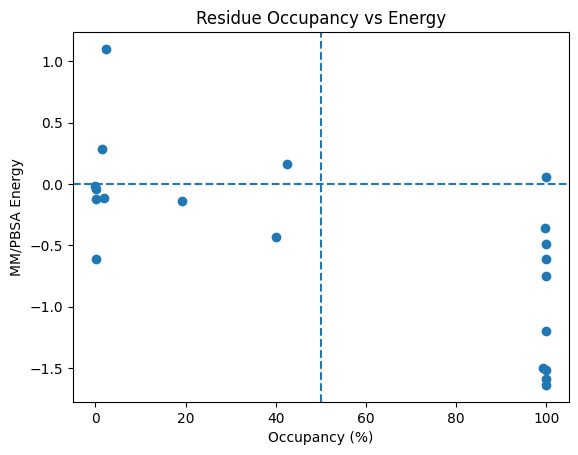

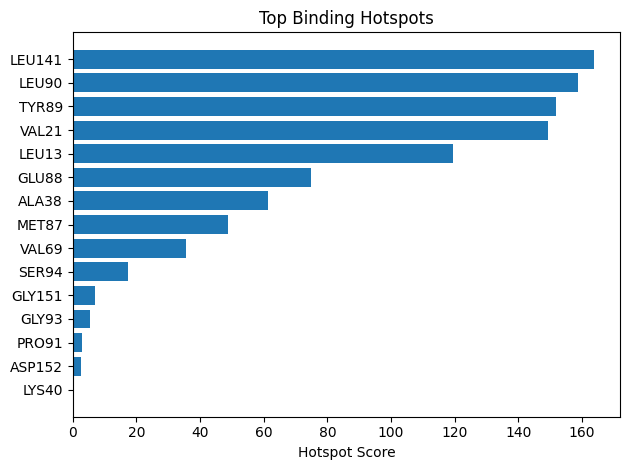

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# INPUT FILE
# =========================
file = "hotspot_residues.csv"  # output from previous step

df = pd.read_csv(file)

# =========================
# STEP 1: TOP HOTSPOTS
# =========================
top = df.sort_values(by="HotspotScore", ascending=False).head(15)

print("\nTOP 15 HOTSPOT RESIDUES:")
print(top[["Resid", "Residue", "Occupancy_percent", "Energy", "HotspotScore"]])

# =========================
# STEP 2: SCATTER PLOT
# Occupancy vs Energy
# =========================
plt.figure()
plt.scatter(df["Occupancy_percent"], df["Energy"])

plt.xlabel("Occupancy (%)")
plt.ylabel("MM/PBSA Energy")
plt.title("Residue Occupancy vs Energy")

plt.axhline(0, linestyle="--")
plt.axvline(50, linestyle="--")

plt.savefig("occupancy_vs_energy.png", dpi=300)
plt.show()

# =========================
# STEP 3: HOTSPOT BAR PLOT
# =========================
top_sorted = top.sort_values(by="HotspotScore")

plt.figure()
plt.barh(
    top_sorted["Residue"].astype(str) + top_sorted["Resid"].astype(str),
    top_sorted["HotspotScore"]
)

plt.xlabel("Hotspot Score")
plt.title("Top Binding Hotspots")

plt.tight_layout()
plt.savefig("hotspot_barplot.png", dpi=300)
plt.show()

In [4]:
import MDAnalysis as mda
import pandas as pd
from collections import defaultdict
import numpy as np

# =========================
# LOAD SYSTEM
# =========================
u = mda.Universe(
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/jak2/st_alignment/aligned_traj/6bbv_no_water.prmtop",
    "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/jak2/st_alignment/aligned_traj/align_6bbv.dcd"
)

# =========================
# SELECT LIGAND ATOMS (CORRECTED)
# =========================
ligand_atoms = u.select_atoms(
    "resname D7D and name C C1 C2 C3 C12 C13 N N1 N4"
)

protein = u.select_atoms("protein")

cutoff = 5.0

print("Ligand atoms:", ligand_atoms.n_atoms)
print("Ligand atom names:", ligand_atoms.names)

if ligand_atoms.n_atoms == 0:
    raise ValueError("Ligand selection failed — check atom names")

# =========================
# STORAGE
# =========================
interaction_counts = defaultdict(int)
total_frames = len(u.trajectory)

# =========================
# TRAJECTORY LOOP
# =========================
for ts in u.trajectory:

    frame_contacts = set()

    # loop over ligand atoms
    for lig_atom in ligand_atoms:

        lig_pos = lig_atom.position

        # compute distances to all protein residues efficiently
        for res in protein.residues:

            res_pos = res.atoms.positions

            # minimum atom-atom distance
            dist = np.linalg.norm(res_pos - lig_pos, axis=1).min()

            if dist <= cutoff:
                key = (res.resid, res.resname, lig_atom.name)
                frame_contacts.add(key)

    # update counts once per frame
    for key in frame_contacts:
        interaction_counts[key] += 1

# =========================
# CONVERT TO DATAFRAME
# =========================
results = []

for (resid, resname, atom), frames in interaction_counts.items():

    occupancy = (frames / total_frames) * 100.0

    results.append([resid, resname, atom, frames, occupancy])

df = pd.DataFrame(
    results,
    columns=["Resid", "Residue", "Ligand_Atom", "Frames", "Occupancy_percent"]
)

# =========================
# SORT
# =========================
df = df.sort_values(by="Occupancy_percent", ascending=False)

# =========================
# SAVE OUTPUT
# =========================
df.to_csv("atomwise_interaction_fingerprint.csv", index=False)

# =========================
# PRINT TOP RESULTS
# =========================
print("\nTop atom-wise interactions:")
print(df.head(20))

Ligand atoms: 9
Ligand atom names: ['C1' 'C2' 'C12' 'C13' 'C3' 'N' 'N4' 'N1' 'C']

Top atom-wise interactions:
    Resid Residue Ligand_Atom  Frames  Occupancy_percent
3      89     TYR           C   50000            100.000
13     89     TYR          N4   50000            100.000
16     88     GLU          N4   50000            100.000
19     90     LEU          C1   50000            100.000
12    141     LEU          C2   50000            100.000
18     38     ALA          N4   50000            100.000
42     90     LEU           C   50000            100.000
38     89     TYR          N1   50000            100.000
60     90     LEU          N1   50000            100.000
67     38     ALA          C1   50000            100.000
68     89     TYR          C1   50000            100.000
66     88     GLU          C1   50000            100.000
36    141     LEU         C12   49999             99.998
53     90     LEU          N4   49999             99.998
58     13     LEU           N   49

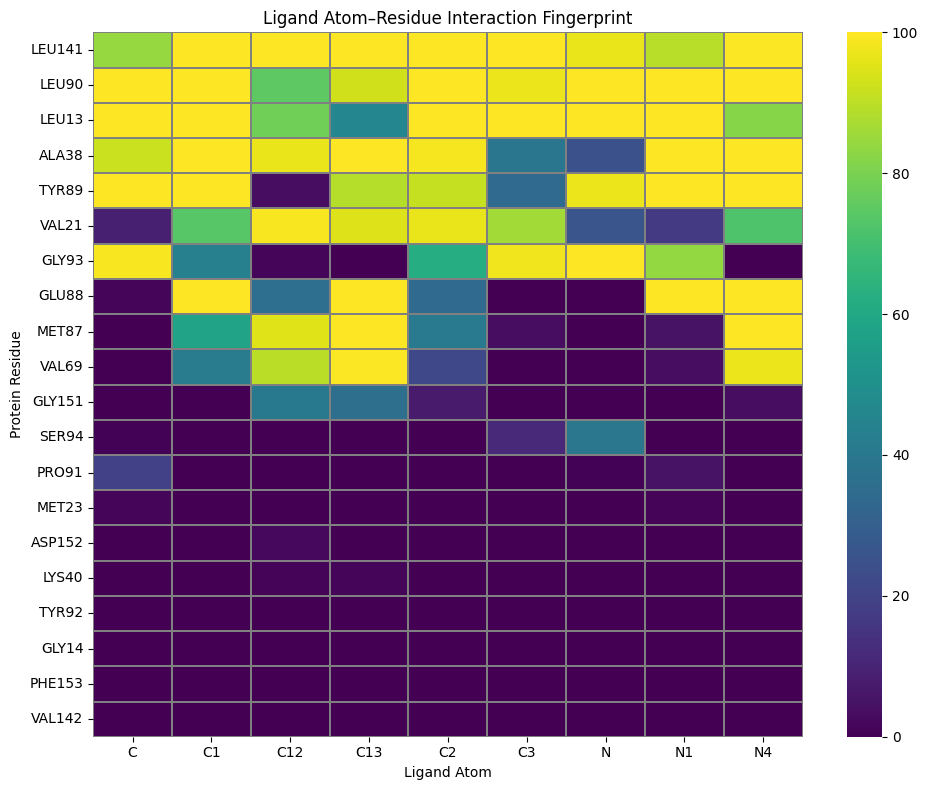

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("atomwise_interaction_fingerprint.csv")

# Keep only needed columns
df = df[["Resid", "Residue", "Ligand_Atom", "Occupancy_percent"]]

# =========================
# CREATE RESIDUE LABEL
# =========================
df["Residue_Label"] = df["Residue"].astype(str) + df["Resid"].astype(str)

# =========================
# PIVOT TABLE (MATRIX)
# =========================
heatmap_data = df.pivot_table(
    index="Residue_Label",
    columns="Ligand_Atom",
    values="Occupancy_percent",
    fill_value=0
)

# =========================
# SORT (optional but important)
# =========================
heatmap_data = heatmap_data.loc[
    heatmap_data.sum(axis=1).sort_values(ascending=False).index
]

# =========================
# PLOT HEATMAP
# =========================
plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data,
    cmap="viridis",
    linewidths=0.3,
    linecolor="gray"
)

plt.title("Ligand Atom–Residue Interaction Fingerprint")
plt.xlabel("Ligand Atom")
plt.ylabel("Protein Residue")

plt.tight_layout()

plt.savefig("interaction_heatmap.png", dpi=300)
plt.show()

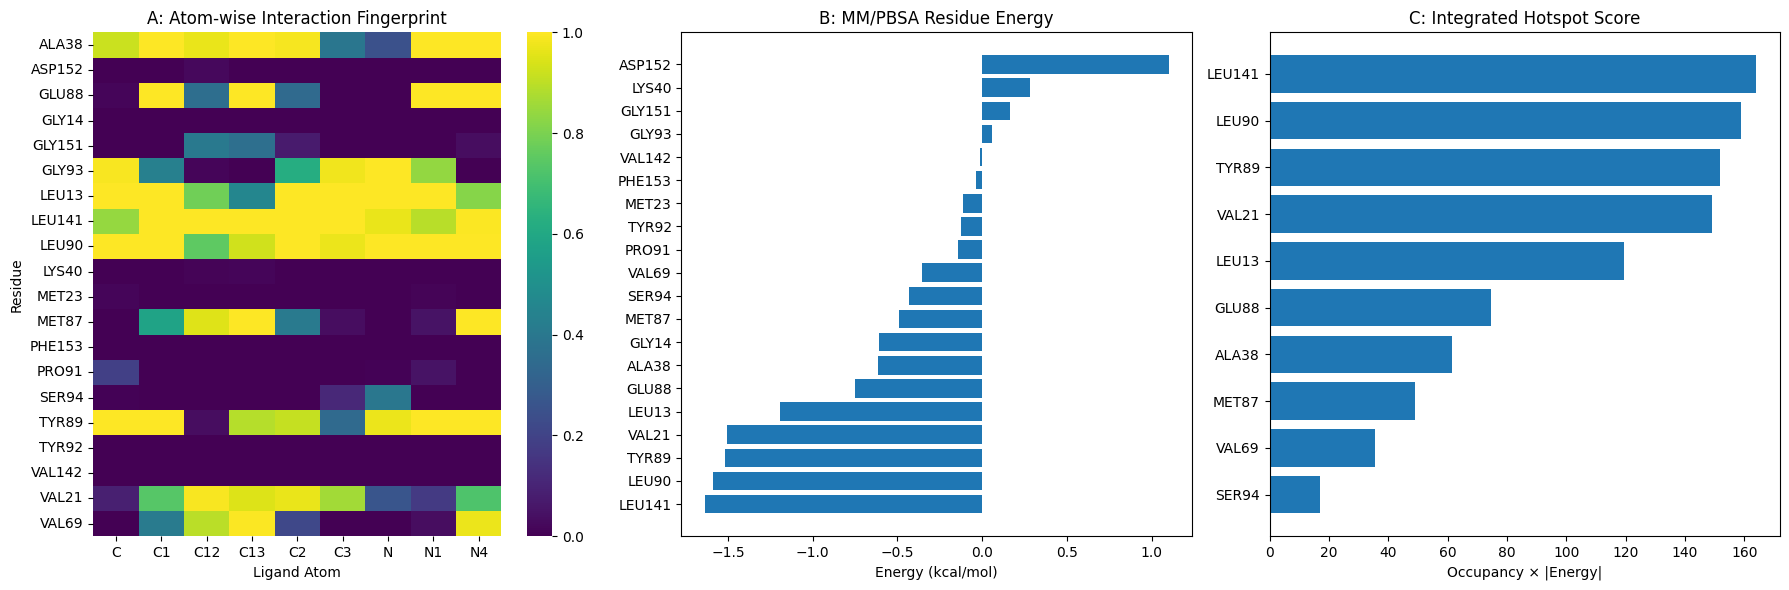


Top hotspots:
    Resid Residue  Occupancy_percent    Energy  HotspotScore
15    141     LEU            100.000 -1.637952    163.795160
10     90     LEU            100.000 -1.588734    158.873440
9      89     TYR            100.000 -1.517147    151.714740
2      21     VAL             99.124 -1.502758    148.959404
0      13     LEU             99.998 -1.195624    119.560029
8      88     GLU            100.000 -0.747526     74.752600
4      38     ALA            100.000 -0.613253     61.325320
7      87     MET             99.986 -0.488314     48.824604
6      69     VAL             99.592 -0.355670     35.421887
14     94     SER             39.754 -0.429428     17.071497
17    151     GLY             40.486  0.163968      6.638425
13     93     GLY             99.906  0.055521      5.546841
11     91     PRO             18.994 -0.142671      2.709897
18    152     ASP              2.246  1.100016      2.470635
5      40     LYS              1.188  0.283223      0.336469


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# INPUT FILES
# =========================
heatmap_file = "atomwise_interaction_fingerprint.csv"
energy_file = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/jak2/6BBV/6BBV_MMPBSA/decomposition_plot.dat"

# =========================
# LOAD HEATMAP DATA
# =========================
df = pd.read_csv(heatmap_file)

# Clean whitespace + enforce consistent types
df["Resid"] = pd.to_numeric(df["Resid"], errors="coerce")
df["Residue"] = df["Residue"].astype(str).str.strip()

df["Residue_Label"] = df["Residue"] + df["Resid"].astype(int).astype(str)

heatmap = df.pivot_table(
    index="Residue_Label",
    columns="Ligand_Atom",
    values="Occupancy_percent",
    fill_value=0
)

heatmap_norm = heatmap / 100.0

# =========================
# LOAD ENERGY DATA
# =========================
energy_data = []

with open(energy_file) as f:
    for line in f:
        parts = line.split()
        if len(parts) < 3:
            continue
        try:
            resname = parts[0].strip()
            resid = int(parts[1])          # FIX: force int
            energy = float(parts[2])
            energy_data.append([resid, resname, energy])
        except:
            continue

energy_df = pd.DataFrame(
    energy_data,
    columns=["Resid", "Residue", "Energy"]
)

# =========================
# BUILD OCCUPANCY PER RESIDUE
# =========================
occ_res = df.groupby(["Resid", "Residue"])["Occupancy_percent"].max().reset_index()

# FIX: enforce same dtype BEFORE merge
occ_res["Resid"] = occ_res["Resid"].astype(int)
energy_df["Resid"] = energy_df["Resid"].astype(int)

occ_res["Residue"] = occ_res["Residue"].astype(str).str.strip()
energy_df["Residue"] = energy_df["Residue"].astype(str).str.strip()

# =========================
# MERGE (FIXED)
# =========================
merged = pd.merge(
    occ_res,
    energy_df,
    on=["Resid", "Residue"],
    how="inner"
)

# =========================
# HOTSPOT SCORE
# =========================
merged["HotspotScore"] = (
    merged["Occupancy_percent"] * np.abs(merged["Energy"])
)

merged = merged.sort_values("HotspotScore", ascending=False)

# =========================
# FIGURE SETUP
# =========================
fig = plt.figure(figsize=(18, 6))

# =========================
# PANEL A: HEATMAP
# =========================
ax1 = plt.subplot(1, 3, 1)
sns.heatmap(
    heatmap_norm,
    cmap="viridis",
    ax=ax1
)
ax1.set_title("A: Atom-wise Interaction Fingerprint")
ax1.set_xlabel("Ligand Atom")
ax1.set_ylabel("Residue")

# =========================
# PANEL B: ENERGY
# =========================
ax2 = plt.subplot(1, 3, 2)

top_energy = merged.sort_values("Energy")

ax2.barh(
    top_energy["Residue"] + top_energy["Resid"].astype(str),
    top_energy["Energy"]
)

ax2.set_title("B: MM/PBSA Residue Energy")
ax2.set_xlabel("Energy (kcal/mol)")

# =========================
# PANEL C: HOTSPOT SCORE
# =========================
ax3 = plt.subplot(1, 3, 3)

top_hotspots = merged.head(10).iloc[::-1]

ax3.barh(
    top_hotspots["Residue"] + top_hotspots["Resid"].astype(str),
    top_hotspots["HotspotScore"]
)

ax3.set_title("C: Integrated Hotspot Score")
ax3.set_xlabel("Occupancy × |Energy|")

plt.tight_layout()
plt.savefig("FINAL_INTEGRATED_FIGURE.png", dpi=300)
plt.show()

# =========================
# SAVE TABLE
# =========================
merged.to_csv("FINAL_hotspot_table.csv", index=False)

print("\nTop hotspots:")
print(merged.head(15))

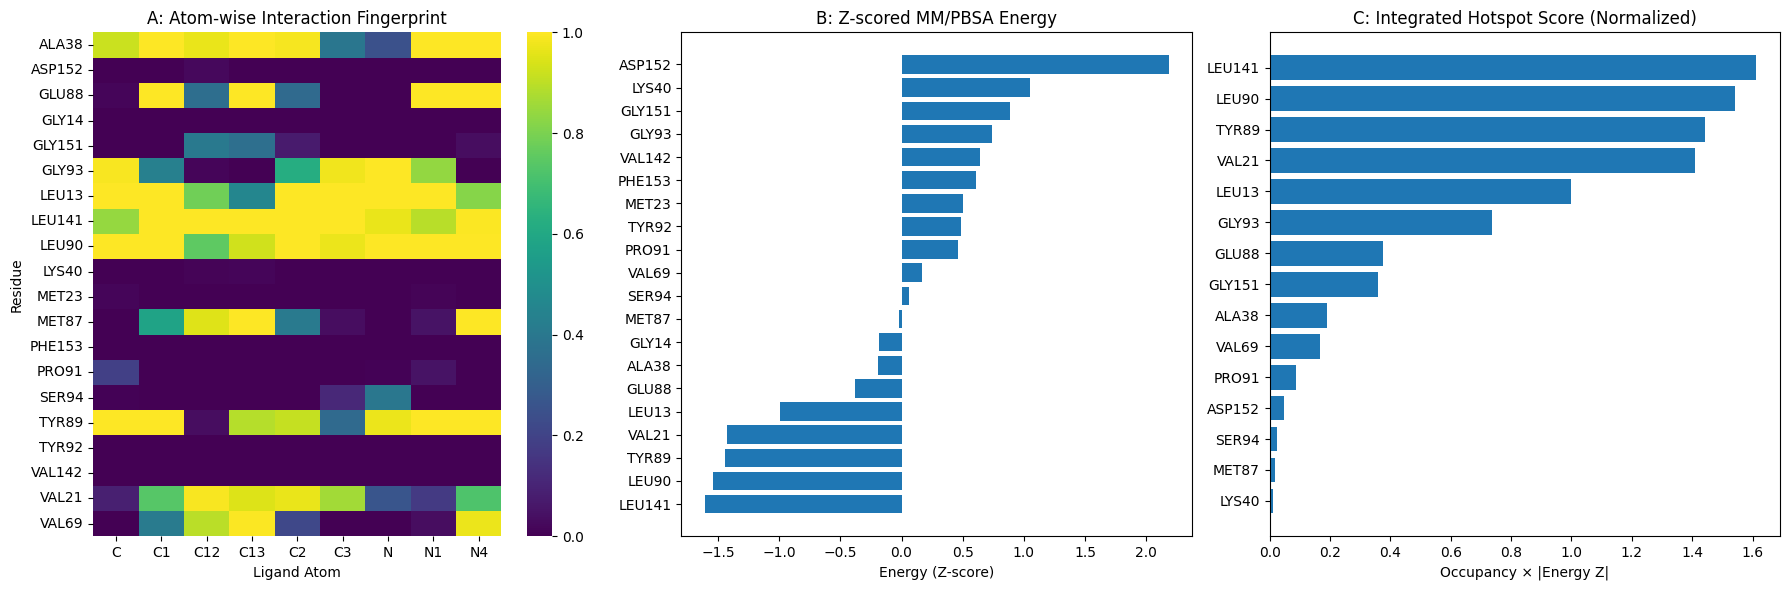


🔥 TOP 15 HOTSPOTS (Integrated):
   Residue  Resid  Occupancy_percent    Energy  HotspotScore
15     LEU    141            100.000 -1.637952      1.610500
10     LEU     90            100.000 -1.588734      1.542303
9      TYR     89            100.000 -1.517147      1.443110
2      VAL     21             99.124 -1.502758      1.410705
0      LEU     13             99.998 -1.195624      0.997576
13     GLY     93             99.906  0.055521      0.735341
8      GLU     88            100.000 -0.747526      0.376696
17     GLY    151             40.486  0.163968      0.358828
4      ALA     38            100.000 -0.613253      0.190643
6      VAL     69             99.592 -0.355670      0.165595
11     PRO     91             18.994 -0.142671      0.087640
18     ASP    152              2.246  1.100016      0.049037
14     SER     94             39.754 -0.429428      0.025471
7      MET     87             99.986 -0.488314      0.017521
5      LYS     40              1.188  0.283223      

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# INPUT FILES
# =========================
heatmap_file = "atomwise_interaction_fingerprint.csv"
energy_file = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/jak2/6BBV/6BBV_MMPBSA/decomposition_plot.dat"

# =========================
# LOAD HEATMAP DATA
# =========================
df = pd.read_csv(heatmap_file)

df["Resid"] = pd.to_numeric(df["Resid"], errors="coerce")
df["Residue"] = df["Residue"].astype(str).str.strip()

df = df.dropna(subset=["Resid"])

df["Resid"] = df["Resid"].astype(int)

df["Residue_Label"] = df["Residue"] + df["Resid"].astype(str)

heatmap = df.pivot_table(
    index="Residue_Label",
    columns="Ligand_Atom",
    values="Occupancy_percent",
    fill_value=0
)

heatmap_norm = heatmap / 100.0

# =========================
# LOAD ENERGY DATA
# =========================
energy_data = []

with open(energy_file) as f:
    for line in f:
        parts = line.split()
        if len(parts) < 3:
            continue
        try:
            resname = parts[0].strip()
            resid = int(parts[1])
            energy = float(parts[2])
            energy_data.append([resid, resname, energy])
        except:
            continue

energy_df = pd.DataFrame(
    energy_data,
    columns=["Resid", "Residue", "Energy"]
)

energy_df["Resid"] = energy_df["Resid"].astype(int)
energy_df["Residue"] = energy_df["Residue"].astype(str).str.strip()

# =========================
# OCCUPANCY PER RESIDUE
# =========================
occ_res = df.groupby(["Resid", "Residue"])["Occupancy_percent"].max().reset_index()
occ_res["Resid"] = occ_res["Resid"].astype(int)
occ_res["Residue"] = occ_res["Residue"].astype(str).str.strip()

# =========================
# MERGE
# =========================
merged = pd.merge(
    occ_res,
    energy_df,
    on=["Resid", "Residue"],
    how="inner"
)

# =========================
# NORMALIZATION (IMPORTANT UPGRADE)
# =========================

# occupancy scaling (0–1)
merged["Occ_norm"] = merged["Occupancy_percent"] / 100.0

# energy Z-score (stabilizes MM/PBSA scale bias)
merged["Energy_z"] = (
    merged["Energy"] - merged["Energy"].mean()
) / merged["Energy"].std()

# absolute energetic contribution
merged["Energy_abs"] = np.abs(merged["Energy_z"])

# =========================
# IMPROVED HOTSPOT SCORE
# =========================
merged["HotspotScore"] = (
    merged["Occ_norm"] * merged["Energy_abs"]
)

merged = merged.sort_values("HotspotScore", ascending=False)

# =========================
# FIGURE SETUP
# =========================
fig = plt.figure(figsize=(18, 6))

# =========================
# PANEL A: HEATMAP
# =========================
ax1 = plt.subplot(1, 3, 1)
sns.heatmap(
    heatmap_norm,
    cmap="viridis",
    ax=ax1
)
ax1.set_title("A: Atom-wise Interaction Fingerprint")
ax1.set_xlabel("Ligand Atom")
ax1.set_ylabel("Residue")

# =========================
# PANEL B: ENERGY (Z-SCALED)
# =========================
ax2 = plt.subplot(1, 3, 2)

top_energy = merged.sort_values("Energy_z")

ax2.barh(
    top_energy["Residue"] + top_energy["Resid"].astype(str),
    top_energy["Energy_z"]
)

ax2.set_title("B: Z-scored MM/PBSA Energy")
ax2.set_xlabel("Energy (Z-score)")

# =========================
# PANEL C: IMPROVED HOTSPOTS
# =========================
ax3 = plt.subplot(1, 3, 3)

top_hotspots = merged.head(15).iloc[::-1]

ax3.barh(
    top_hotspots["Residue"] + top_hotspots["Resid"].astype(str),
    top_hotspots["HotspotScore"]
)

ax3.set_title("C: Integrated Hotspot Score (Normalized)")
ax3.set_xlabel("Occupancy × |Energy Z|")

plt.tight_layout()
plt.savefig("FINAL_INTEGRATED_FIGURE.png", dpi=300)
plt.show()

# =========================
# SAVE OUTPUT
# =========================
merged.to_csv("FINAL_hotspot_table.csv", index=False)

# =========================
# EXTRA SCIENTIFIC OUTPUTS
# =========================
print("\n🔥 TOP 15 HOTSPOTS (Integrated):")
print(merged[["Residue", "Resid", "Occupancy_percent", "Energy", "HotspotScore"]].head(15))

print("\n⚡ TOP ENERGY CONTRIBUTORS:")
print(merged.sort_values("Energy_z")[["Residue", "Resid", "Energy", "Energy_z"]].head(10))

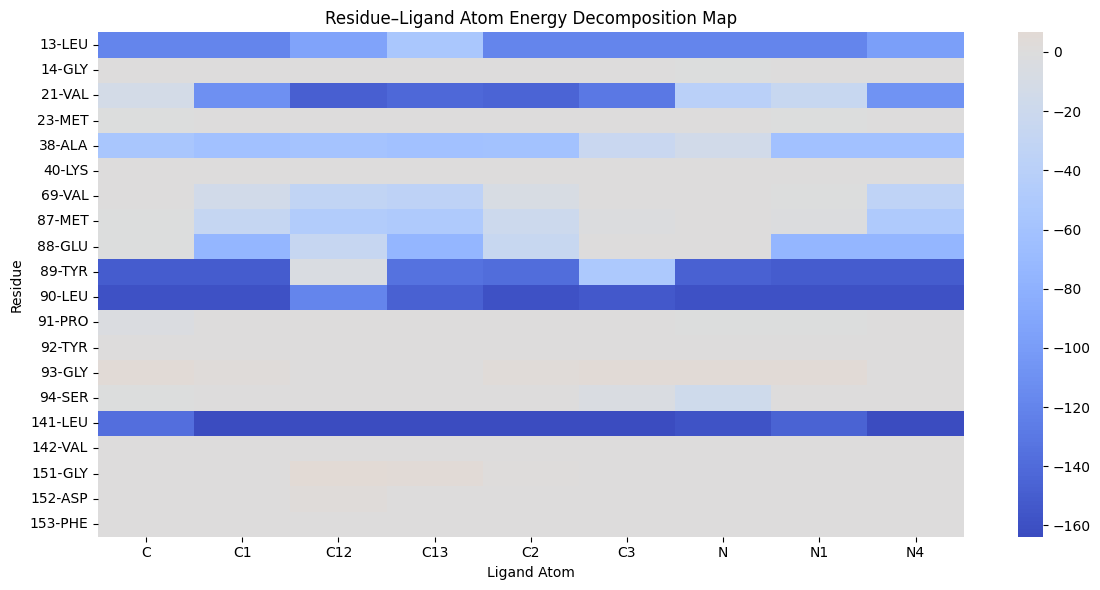

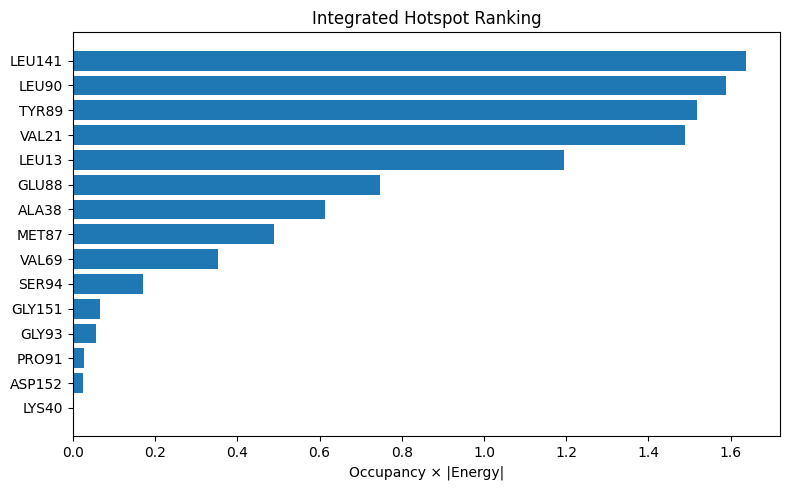


🔥 Top residue–ligand hotspots:
   Residue  Resid    Energy  HotspotScore
15     LEU    141 -1.637952      1.637952
10     LEU     90 -1.588734      1.588734
9      TYR     89 -1.517147      1.517147
2      VAL     21 -1.502758      1.489594
0      LEU     13 -1.195624      1.195600
8      GLU     88 -0.747526      0.747526
4      ALA     38 -0.613253      0.613253
7      MET     87 -0.488314      0.488246
6      VAL     69 -0.355670      0.354219
14     SER     94 -0.429428      0.170715
17     GLY    151  0.163968      0.066384
13     GLY     93  0.055521      0.055468
11     PRO     91 -0.142671      0.027099
18     ASP    152  1.100016      0.024706
5      LYS     40  0.283223      0.003365

⚡ Energy sanity check:
   Resid    Energy
0     13 -1.195624
1     14 -0.608291
2     21 -1.502758
3     23 -0.115134
4     38 -0.613253
5     40  0.283223
6     69 -0.355670
7     87 -0.488314
8     88 -0.747526
9     89 -1.517147


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# INPUT FILES
# =========================
heatmap_file = "atomwise_interaction_fingerprint.csv"
energy_file = "/media/thsti/6938FCB134D4F6F7/Dr.Meenakshi/fda/md_simulations/jak2/6BBV/6BBV_MMPBSA/decomposition_plot.dat"

# =========================
# LOAD INTERACTION DATA
# =========================
df = pd.read_csv(heatmap_file)

df["Resid"] = pd.to_numeric(df["Resid"], errors="coerce")
df = df.dropna(subset=["Resid"])
df["Resid"] = df["Resid"].astype(int)
df["Residue"] = df["Residue"].astype(str).str.strip()

# =========================
# RESIDUE–ATOM OCCUPANCY MATRIX
# =========================
occ_matrix = df.pivot_table(
    index=["Resid", "Residue"],
    columns="Ligand_Atom",
    values="Occupancy_percent",
    aggfunc="mean",
    fill_value=0
)

# normalize occupancy
occ_norm = occ_matrix.div(occ_matrix.sum(axis=1), axis=0).fillna(0)

# =========================
# LOAD ENERGY DATA
# =========================
energy_data = []

with open(energy_file) as f:
    for line in f:
        parts = line.split()
        if len(parts) < 3:
            continue
        try:
            resid = int(parts[1])
            energy = float(parts[2])
            energy_data.append([resid, energy])
        except:
            continue

energy_df = pd.DataFrame(energy_data, columns=["Resid", "Energy"])

# collapse duplicates safely
energy_df = energy_df.groupby("Resid", as_index=False).mean()

# =========================
# ENERGY–OCCUPANCY MERGE (FIXED CORE STEP)
# =========================
occ_flat = occ_matrix.reset_index()

merged = occ_flat.merge(
    energy_df,
    on="Resid",
    how="inner"
)

# =========================
# ENERGY DECOMPOSITION MAP
# =========================
ligand_atoms = occ_matrix.columns

energy_map = merged[ligand_atoms].mul(
    merged["Energy"], axis=0
)

atom_energy_map = pd.concat(
    [merged[["Resid", "Residue"]], energy_map],
    axis=1
)

# =========================
# HOTSPOT SCORE (FIXED + CONSISTENT)
# =========================
merged["Max_Occupancy"] = merged[ligand_atoms].max(axis=1)

merged["HotspotScore"] = (
    merged["Max_Occupancy"] / 100.0
) * np.abs(merged["Energy"])

hotspot = merged.sort_values("HotspotScore", ascending=False)

# =========================
# PLOT 1: ENERGY DECOMPOSITION MAP
# =========================
plt.figure(figsize=(12, 6))

heatmap_df = atom_energy_map.set_index(["Resid", "Residue"]).drop(columns=[])

sns.heatmap(
    heatmap_df[ligand_atoms],
    cmap="coolwarm",
    center=0
)

plt.title("Residue–Ligand Atom Energy Decomposition Map")
plt.xlabel("Ligand Atom")
plt.ylabel("Residue")
plt.tight_layout()
plt.savefig("energy_decomposition_map.png", dpi=300)
plt.show()

# =========================
# PLOT 2: HOTSPOT RANKING
# =========================
plt.figure(figsize=(8, 5))

top = hotspot.head(15).iloc[::-1]

labels = [
    f"{row.Residue}{row.Resid}"
    for _, row in top.iterrows()
]

plt.barh(labels, top["HotspotScore"])
plt.title("Integrated Hotspot Ranking")
plt.xlabel("Occupancy × |Energy|")
plt.tight_layout()
plt.savefig("hotspot_ranking.png", dpi=300)
plt.show()

# =========================
# SAVE OUTPUTS
# =========================
atom_energy_map.to_csv("atom_residue_energy_map.csv", index=False)
hotspot.to_csv("hotspot_summary.csv", index=False)

# =========================
# CONSISTENCY CHECK
# =========================
print("\n🔥 Top residue–ligand hotspots:")
print(hotspot[["Residue", "Resid", "Energy", "HotspotScore"]].head(15))

print("\n⚡ Energy sanity check:")
print(merged[["Resid", "Energy"]].head(10))